# Preliminares

## Importación de Librerias  

In [ ]:
# Importamos todo lo que usaremos
from scipy.stats import poisson
from scipy.stats import bernoulli
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import table
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import mpmath
import math
import random

## Definición de funciones para la modelación


In [ ]:
#Seleccionara dos elementos aleatoriamente uno despues del otro
def SeleccionaElementos(lista):
    lista1=lista.copy()
    l1=len(lista1)
    s1=sum(lista1)
    p1=random.randint(1,s1)
    k1=1
    i1=0
    while(k1<=p1):
        k1=lista1[i1]+k1
        i1=i1+1

    lista1[i1-1]=lista1[i1-1]-1
    lista2=lista1.copy()
    l2=len(lista2)
    s2=sum(lista2)
    p2=random.randint(1,s2)
    k2=1
    i2=0
    while(k2<=p2):
        k2=lista2[i2]+k2
        i2=i2+1
    lista2[i2-1]=lista2[i2-1]-1
    return(i1-1,i2-1)
#Ejecutaremos la Coalescencia
def Coalescencia(lista):
    i,j=SeleccionaElementos(lista)
    if(i!=j):
        if(i<j):
            lista[i]=lista[i]+lista[j]-1
            lista.pop(j)
        else:
            lista[j]=lista[i]+lista[j]-1
            lista.pop(i)

    else:
        lista[i]=lista[i]-1
    return(lista)
#Usaremos Coalescenciaij cuando necesitemos conocer exactamente que bloques fueron elegidos para coalescer.
def Coalescenciaij(lista):
    i,j=SeleccionaElementos(lista)
    if(i!=j):
        if(i<j):
            lista[i]=lista[i]+lista[j]-1
            lista.pop(j)
        else:
            lista[j]=lista[i]+lista[j]-1
            lista.pop(i)

    else:
        lista[i]=lista[i]-1
    return(lista,i,j)


#mul es la distribución pedida para las bifurcaciones
def Bifurcacion(lista):
    mul=DistribucionBifu()
    while(mul<1):
      mul=DistribucionBifu()
    l=len(lista)
    s=sum(lista)
    p=random.randint(1,s)
    k=1
    i=0
    while(k<=p):
        k=lista[i]+k
        i=i+1
    lista[i-1]=lista[i-1]+mul-1
    return(lista)


#Promedio de Tiempos para m veces el modelo
def TiempoPromedioUltimo(tamano_lista,lista,sigma,configuracion,num_ejecuciones):
    T=[]
    for i in range(1,num_ejecuciones+1):
        T.append(ModeloTiemposUltimo(tamano_lista,lista,sigma,configuracion))

    Promedio=sum(T)/len(T)

    print(Promedio)


#Promedio de Tiempos para m veces el modelo
def TiempoPromedioPrimer(tamano_lista,lista,sigma,configuracion,num_ejecuciones):
    T=[]
    for i in range(1,num_ejecuciones+1):
        T.append(ModeloTiemposPrimer(tamano_lista,lista,sigma,configuracion))

    Promedio=sum(T)/len(T)

    print(Promedio)

# Función para analizar los datos
def analyze_data(data, title):
    mean = np.mean(data)
    median = np.median(data)
    std_dev = np.std(data)
    variance = np.var(data)
    skewness = stats.skew(data)
    kurtosis = stats.kurtosis(data)
    coef_var = std_dev / mean


    print(f"Análisis para {title}:")
    print(f"  Media: {mean}")
    print(f"  Mediana: {median}")
    print(f"  Desviación estándar: {std_dev}")
    print(f"  Varianza: {variance}")
    print(f"  Sesgo (Asimetría): {skewness}")
    print(f"  Curtosis: {kurtosis}")
    print(f"  Coeficiente de variación: {coef_var}\n")

    # Crear histograma sin la superposición de la distribución normal
    plt.hist(data, bins=50, edgecolor='black', alpha=0.6)
    plt.title(f'Histograma ({title})')
    plt.xlabel('Valor')
    plt.ylabel('Frecuencia')
    plt.show()

#Con el objetivo de Comparar el bloque que coalescio con el que no, definimos dos funciones para el cuociente y la resta.
def CuocientePromedioPrimeraConexidad(tamano_lista,lista,sigma,configuracion,num_ejecuciones):

    T=[]
    for i in range(1,num_ejecuciones+1):
        lista1=lista.copy()
        lista1,l,k=ModeloHistogramaPrimer(tamano_lista,lista,sigma,configuracion)
        tamaño=len(lista1)
        j=0
        if(l<k):
            while(j!=-1):
                if(j!=l):

                    peq=j
                    j=-2
                j=j+1

            BloqueC=lista1[l]

            BloqueNoC=lista1[peq]
        else:
            while(j!=-1):
                if(j!=k):

                    peq=j
                    j=-2
                j=j+1
            BloqueC=lista1[k]
            BloqueNoC=lista1[peq]

        T.append(BloqueNoC/BloqueC)


    return(T)

def RestaPromedioPrimeraConexidad(tamano_lista,lista,sigma,configuracion,num_ejecuciones):
    T=[]

    for i in range(1,num_ejecuciones+1):
        lista1,l,k=ModeloHistogramaPrimer(tamano_lista,lista,sigma,configuracion)
        tamaño=len(lista)
        j=0
        if(l<k):
            while(j!=-1):
                if(j!=l):

                    peq=j
                    j=-2
                j=j+1

            BloqueC=lista1[l]

            BloqueNoC=lista1[peq]
        else:
            while(j!=-1):
                if(j!=k):

                    peq=j
                    j=-2
                j=j+1
            BloqueC=lista1[k]
            BloqueNoC=lista1[peq]

        T.append(BloqueC-BloqueNoC)


    return(T)

## Creacion de los modelos de Tiempos, Graficos y  para los Histogramas.

Creación de Modelo de Tiempos N=2000




In [ ]:
def ModeloTiemposPrimer(tamano_lista,lista,sigma,configuracion):
    if(configuracion==True):
        lista1=lista.copy()
    else:
        lista= [DistribucionBlo()for _ in range(tamano_lista)]
        for i in range(tamano_lista):
            while(lista[i]<1):
              lista[i]=DistribucionBlo()
        lista1=lista.copy()
    s=sum(lista1)
    lambda1=s*(s-1)/2
    lambda2=sigma*s
    N=20000
    bp=(lambda1+lambda2)/N
    i=0
    lista0=lista.copy()
    a=len(lista0)
    while(len(lista1)==a):
        if(np.random.binomial(n=1, p=bp)==1):

            if(random.uniform(0, 1)<= lambda1/(lambda1+lambda2)):
                lista1=Coalescencia(lista1)
            else:
                lista1=Bifurcacion(lista1)
            s=sum(lista1)
            lambda1=s*(s-1)/2
            lambda2=sigma*s
            bp=(lambda1+lambda2)/N
        tiempos=i/N
        i=i+1
    return(tiempos)
def ModeloTiemposUltimo(tamano_lista,lista,sigma,configuracion):
    if(configuracion==True):
        lista1=lista.copy()
    else:
        lista= [DistribucionBlo()for _ in range(tamano_lista)]
        for i in range(tamano_lista):
            while(lista[i]<1):
              lista[i]=DistribucionBlo()
        lista1=lista.copy()
    s=sum(lista1)
    lambda1=s*(s-1)/2
    lambda2=sigma*s
    N=20000
    bp=(lambda1+lambda2)/N
    i=0
    while(len(lista1)>1):
        if(np.random.binomial(n=1, p=bp)==1):
            if(random.uniform(0, 1)<= lambda1/(lambda1+lambda2)):
                lista1=Coalescencia(lista1)
            else:
                lista1=Bifurcacion(lista1)
            s=sum(lista1)
            lambda1=s*(s-1)/2
            lambda2=sigma*s
            bp=(lambda1+lambda2)/N


        tiempos=i/N
        i=i+1
    return(tiempos)


Creación de Modelo Grafico N=2000

In [ ]:
def ModeloGraficoPrimerConex(tamano_lista, lista, sigma, configuracion):
    if configuracion:
        lista1 = [int(x) for x in lista.copy()]
    else:
        lista = [int(DistribucionBlo()) for _ in range(tamano_lista)]
        for i in range(tamano_lista):
            while lista[i] < 1:
                lista[i] = int(DistribucionBlo())
        lista1 = lista.copy()

    s = sum(lista1)
    lambda1 = s * (s - 1) / 2
    lambda2 = sigma * s
    N = 20000
    bp = (lambda1 + lambda2) / N
    i = 0
    lista0 = lista.copy()
    a = len(lista0)
    print(lista1)

    while len(lista1) == a:
        if np.random.binomial(n=1, p=bp) == 1:
            if random.uniform(0, 1) <= lambda1 / (lambda1 + lambda2):
                lista1 = [int(x) for x in Coalescencia(lista1)]
            else:
                lista1 = [int(x) for x in Bifurcacion(lista1)]
            print(lista1)
            s = sum(lista1)
            lambda1 = s * (s - 1) / 2
            lambda2 = sigma * s
            bp = (lambda1 + lambda2) / N
        i += 1

    return lista1


def ModeloGraficoUltimaConex(tamano_lista, lista, sigma, configuracion):
    if configuracion:
        lista1 = [int(x) for x in lista.copy()]
    else:
        lista = [int(DistribucionBlo()) for _ in range(tamano_lista)]
        for i in range(tamano_lista):
            while lista[i] < 1:
                lista[i] = int(DistribucionBlo())
        lista1 = lista.copy()

    s = sum(lista1)
    lambda1 = s * (s - 1) / 2
    lambda2 = sigma * s
    N = 20000
    bp = (lambda1 + lambda2) / N
    i = 0
    lista0 = lista.copy()
    print(lista1)

    while len(lista1) > 1:
        if np.random.binomial(n=1, p=bp) == 1:
            if random.uniform(0, 1) <= lambda1 / (lambda1 + lambda2):
                lista1 = [int(x) for x in Coalescencia(lista1)]
            else:
                lista1 = [int(x) for x in Bifurcacion(lista1)]
            print(lista1)
            s = sum(lista1)
            lambda1 = s * (s - 1) / 2
            lambda2 = sigma * s
            bp = (lambda1 + lambda2) / N
        i += 1

    return lista1


Creación de Modelo para Futuros Histogramas, N=2000

In [ ]:
#Realizaremos un Modelo para Comparar el bloque que coalescio en \tau con alguno que no.
def ModeloHistogramaPrimer(tamano_lista,lista,sigma,configuracion):
    if(configuracion==True):
        lista1=lista.copy()
    else:
        lista= [DistribucionBlo()for _ in range(tamano_lista)]
        for i in range(tamano_lista):
            while(lista[i]<1):
              lista[i]=DistribucionBlo()
        lista1=lista.copy()
    s=sum(lista1)
    lambda1=s*(s-1)/2
    lambda2=sigma*s
    N=40000
    bp=(lambda1+lambda2)/N
    i=0
    lista0=lista.copy()
    a=len(lista0)
    while(len(lista1)==a):
        if(np.random.binomial(n=1, p=bp)==1):

            if(random.uniform(0, 1)<= lambda1/(lambda1+lambda2)):
                lista1,l,k=Coalescenciaij(lista1)
            else:
                lista1=Bifurcacion(lista1)
            s=sum(lista1)
            lambda1=s*(s-1)/2
            lambda2=sigma*s
            bp=(lambda1+lambda2)/N
        i=i+1
    return(lista1,l,k)

## Definición de los ejecutables para los modelos

In [ ]:
#Ejecutara el modelo ccrrespondiente dependiendo de las respuestas del usuario
def ejecutar_simulacion(tamano_lista, lista, sigma, configuracion,num_ejecuciones):
    if(primer_momento==True):
        print("El tiempo promedio de la primera conexión entre familias es de: ")
        TiempoPromedioPrimer(tamano_lista,lista,sigma,configuracion,num_ejecuciones)
    else:
        print("El tiempo promedio de la ultima conexión entre familias es de: ")
        TiempoPromedioUltimo(tamano_lista,lista,sigma,configuracion,num_ejecuciones)

def ejecutar_simulacion_grafica(tamano_lista, lista, sigma, configuracion):
    if(primer_momento==True):
         print("Un ejemplo del Comportamiento del Modelo para la primera conexión es: ")
         ModeloGraficoPrimerConex(tamano_lista,lista,sigma,configuracion)
    else:
         print("Un ejemplo del Comportamiento del Modelo para la ultima conexión es: ")
         ModeloGraficoUltimaConex(tamano_lista,lista,sigma,configuracion)

def HistogramaResta(tamano_lista, lista, sigma, configuracion,num_ejecuciones):
    data=RestaPromedioPrimeraConexidad(tamano_lista,lista,sigma,configuracion,num_ejecuciones)
    if(configuracion==True):
        titulo = r"$\sigma = {}, X = {}$".format(sigma,len(lista) )
    else:
        titulo = r"$\sigma = {}, X = {}$".format(sigma,tamano_lista )
    analyze_data(data, titulo)
def HistogramaCuociente(tamano_lista, lista, sigma, configuracion,num_ejecuciones):
    data=CuocientePromedioPrimeraConexidad(tamano_lista,lista,sigma,configuracion,num_ejecuciones)
    if(configuracion==True):
        titulo = r"$\sigma = {}, X = {}$".format(sigma,len(lista) )
    else:
        titulo = r"$\sigma = {}, X = {}$".format(sigma,tamano_lista )
    analyze_data(data, titulo)


# Definiciones Generales del ASG

In [ ]:

# Preguntar si se desea para el primer momento de conexión entre bloques o hasta el final del proceso
configuracionbloques = input("¿Desea dar la configuración de bloques o definirla dada una distribución? (conf/dis): ").strip().lower()

# Guardar True si la respuesta es "conf" y False si es "dis"
configuracion = configuracionbloques == 'conf'

if (configuracion==True):
    # Pedir al usuario que ingrese una lista en formato de lista de Python
    lista_usuario = input("Ingrese una lista de valores en formato de lista de Python (ej:  [1, 2, 3, 4] ): ")

    # Evaluar la cadena de entrada para convertirla en una lista de Python
    lista = eval(lista_usuario)
    # Pedir al usuario que ingrese la distribución completa o un valor para las bifurcaciones
    print("Definiremos el mecanismo para las Bifurcaciones, estara condicionada a ser mayor que 0")
    entrada_usuario2 = input("Ingrese la distribución de probabilidad (ej: 2 ) o un valor: ")
    # Definir la función
    def DistribucionBifu():
        return eval(entrada_usuario2)
   # Ejemplo de cómo usar la función
    nuevo_valor = DistribucionBifu()
    print(f"Ejemplo de la distribución dada: {nuevo_valor}")
    sigma = float(input("¿Con que tasa ocurriran las bifuraciones?: "))
    # Preguntar si se desea para el primer momento de conexión entre bloques o hasta el final del proceso
    respuesta_usuario3 = input("¿Desea valores para el primer momento de conexión entre bloques o hasta el ultimo? (primer/ultimo): ").strip().lower()

    # Guardar True si la respuesta es "primer" y False si es "ultimo"
    primer_momento = respuesta_usuario3 == 'primer'


    num_ejecuciones = int(input("¿Cuántas veces desea ejecutar el modelo para promediarlo?: "))
    print("Se ha definido que trabajaremos con una configuración inicial de '", lista_usuario,
      "', con las bifurcaciones dadas por la distribución '", entrada_usuario2,
      "' a tasa ", sigma, " y se ejecutará la simulación una cantidad de ", num_ejecuciones,
      " hasta el ", respuesta_usuario3, " momento de conexión.")
    # Definimos el tamaño solo para escribir el modelo general
    tamano_lista=0
else:
    # Pedir al usuario que ingrese el tamaño de la lista de bloques junto a la distribución completa o un valor para los

    print("Definiremos la distribución de los bloques y la cantidad de ellos")
    # Pedir al usuario que ingrese la distribución completa
    print("¡Alerta!")
    print("La distribución para los bloques estara condicionada a ser mayor que 0.")
    entrada_usuario1 = input("Ingrese la distribución de probabilidad (ej: np.random.poisson(6, 1)[0] ): ")

    # Pedir al usuario que ingrese el tamaño de la lista
    tamano_lista = int(input("Ingrese el tamaño de la lista: "))

    # Definir la función para obtener valores de la distribución
    def DistribucionBlo():
        return eval(entrada_usuario1)

    # Generar la lista con el tamaño especificado
    lista_valores = [DistribucionBlo()for _ in range(tamano_lista)]

    print(f"Ejemplo de lista: {lista_valores}")
    # Pedir al usuario que ingrese la distribución completa o un valor para las bifurcaciones
    print("Definiremos el mecanismo para las Bifurcaciones, estara condicionada a ser mayor que 0")
    entrada_usuario2 = input("Ingrese la distribución de probabilidad (ej: 2) o un valor: ")

    # Definir la función
    def DistribucionBifu():
        return eval(entrada_usuario2)

    # Ahora puedes usar obtener_valor() en cualquier momento para generar nuevos valores de la distribución
    # Ejemplo de cómo usar la función
    nuevo_valor = DistribucionBifu()
    print(f"Ejemplo de la distribución dada: {nuevo_valor}")
    sigma = float(input("¿Con que tasa ocurriran las bifuraciones?: "))
    # Preguntar si se desea para el primer momento de conexión entre bloques o hasta el final del proceso
    respuesta_usuario3 = input("¿Desea valores para el primer momento de conexión entre bloques o hasta el ultimo? (primer/ultimo): ").strip().lower()

    # Guardar True si la respuesta es "primer" y False si es "ultimo"
    primer_momento = respuesta_usuario3 == 'primer'


    num_ejecuciones = int(input("¿Cuántas veces desea ejecutar el modelo para promediarlo?: "))
    print("Se ha definido que trabajaremos con una lista de tamaño ",tamano_lista," que se genera dada una distribución ´",entrada_usuario1,"´, para bifurcaciones con distribución ´",entrada_usuario2,"´ a tasa ",sigma," y se ejecutara la simulación una cantidad de ",num_ejecuciones ," hasta el ",respuesta_usuario3," momento de conexión.")
    # Definimos la lista solo para escribir el modelo general
    lista=[]




¿Desea dar la configuración de bloques o definirla dada una distribución? (conf/dis): conf
Ingrese una lista de valores en formato de lista de Python (ej:  [1, 2, 3, 4] ): [1, 2, 3, 4]
Definiremos el mecanismo para las Bifurcaciones, estara condicionada a ser mayor que 0
Ingrese la distribución de probabilidad (ej: 2 ) o un valor: 2
Ejemplo de la distribución dada: 2
¿Con que tasa ocurriran las bifuraciones?: 3
¿Desea valores para el primer momento de conexión entre bloques o hasta el ultimo? (primer/ultimo): primer
¿Cuántas veces desea ejecutar el modelo para promediarlo?: 10
Se ha definido que trabajaremos con una configuración inicial de ' [1, 2, 3, 4] ', con las bifurcaciones dadas por la distribución ' 2 ' a tasa  3.0  y se ejecutará la simulación una cantidad de  10  hasta el  primer  momento de conexión.


#Ejecución De las Simulaciones

Para obtener tiempos

In [ ]:
ejecutar_simulacion(tamano_lista, lista, sigma, configuracion,num_ejecuciones)

El tiempo promedio de la primera conexión entre familias es de: 
0.027495


Ejemplo de la manera grafica del comportamiento de las simulaciones


In [ ]:
ejecutar_simulacion_grafica(tamano_lista, lista, sigma, configuracion)

Un ejemplo del Comportamiento del Modelo para la primera conexión es: 
[1, 2, 3, 4]
[1, 5, 3]


# Graficos y Resultados

## Histogramas Para Comparar Bloque que Coalescio con el que no

Resta

Análisis para $\sigma = 3.0, X = 4$:
  Media: 2.8
  Mediana: 3.5
  Desviación estándar: 2.039607805437114
  Varianza: 4.16
  Sesgo (Asimetría): -0.43560410785500464
  Curtosis: -1.1830621301775148
  Coeficiente de variación: 0.7284313590846836



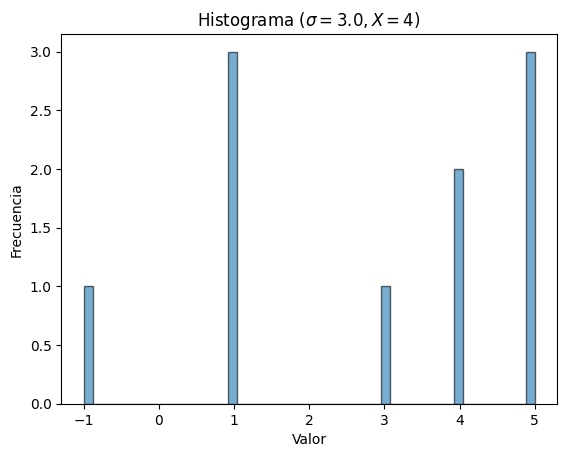

In [ ]:
HistogramaResta(tamano_lista, lista, sigma, configuracion,num_ejecuciones)

Análisis para $\sigma = 3.0, X = 4$:
  Media: 0.5926190476190476
  Mediana: 0.3333333333333333
  Desviación estándar: 0.5109730724075621
  Varianza: 0.26109348072562366
  Sesgo (Asimetría): 0.9422804709891608
  Curtosis: -0.7940173533941439
  Coeficiente de variación: 0.8622285673410047



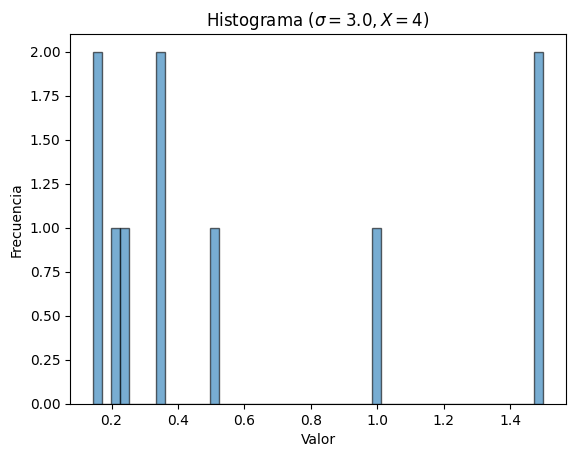

In [ ]:
HistogramaCuociente(tamano_lista, lista, sigma, configuracion,num_ejecuciones)

## Simulaciones para bloques de 1 linea

En esta sección presentaremos los resultados obtenidos al realizar las simulaciones.

In [ ]:
#Definimos 2 data frame donde registramos los resultados de los tiempos tras variaciones de sigma.

# Crear un diccionario con los datos
DataPrimeraCoalescencia = {
    'Sigma': [0, 0.5, 1, 5,7, 10],
    '#X=2': [0.999, 0.602, 0.431, 0.157,0.118,0.090],
    '#X=3': [0.338, 0.244, 0.217, 0.092,0.070,0.057],
    '#X=4': [0.161, 0.133, 0.117, 0.059,0.051,0.041],
    '#X=10': [0.022, 0.021, 0.019, 0.014,0.013,0.011]
}

# Crear un diccionario con los datos
DataUltimaCoalescencia = {
    'Sigma': [0, 0.5, 1, 5,7, 10],
    '#X=2': [1.001, 0.604, 0.441,0.154,0.117,0.087],
    '#X=3': [1.321, 0.693, 0.488, 0.151,0.117,0.087],
    '#X=4': [1.473, 0.759, 0.493, 0.142,0.110,0.081],
    '#X=10': [1.820, 0.716,0.444, 0.124,0.092,0.071]
}
# Crear el DataFrame
df0 = pd.DataFrame(DataPrimeraCoalescencia)
# Crear el DataFrame
df1 = pd.DataFrame(DataUltimaCoalescencia)
# Mostrar el DataFrame

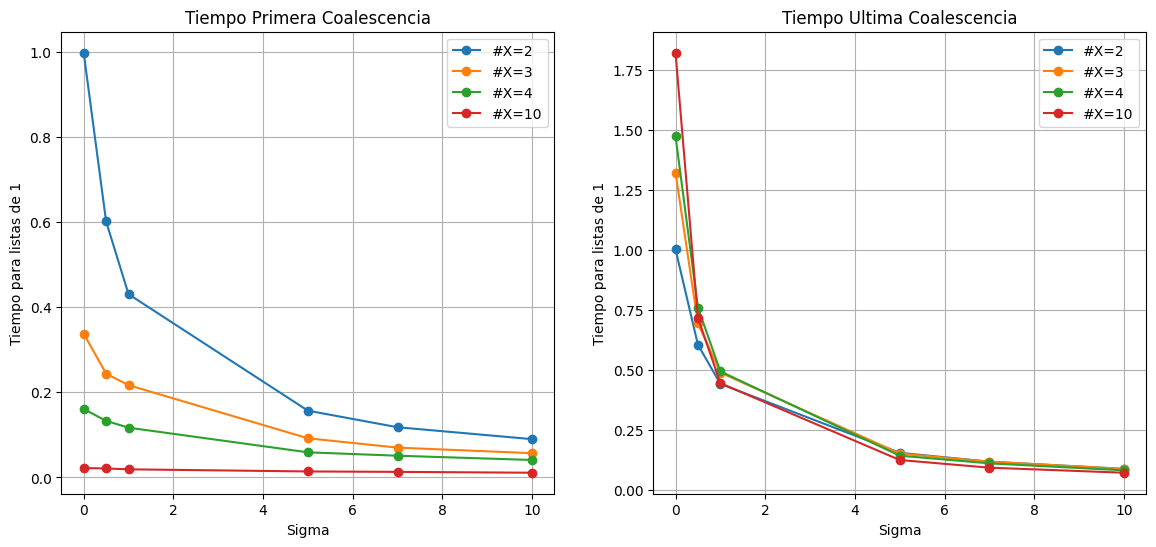

In [ ]:

#Graficos de los data frame anteriores.
columna_fija = 'Sigma'
# Definir las columnas variables que quieres graficar para el primer conjunto de datos
columnas_variables_primera = ['#X=2', '#X=3', '#X=4', '#X=10']

# Definir las columnas variables que quieres graficar para el segundo conjunto de datos
columnas_variables_ultima = ['#X=2', '#X=3', '#X=4', '#X=10']

# Graficar
plt.figure(figsize=(14, 6))

# Graficar para el primer conjunto de datos
plt.subplot(1, 2, 1)
for col in columnas_variables_primera:
    plt.plot(df0[columna_fija], df0[col], marker='o', label=col)
plt.title('Tiempo Primera Coalescencia')
plt.xlabel('Sigma')
plt.ylabel('Tiempo para listas de 1')
plt.legend()
plt.grid(True)

# Graficar para el segundo conjunto de datos
plt.subplot(1, 2, 2)
for col in columnas_variables_ultima:
    plt.plot(df1[columna_fija], df1[col], marker='o', label=col)
plt.title('Tiempo Ultima Coalescencia')
plt.xlabel('Sigma')
plt.ylabel('Tiempo para listas de 1')
plt.legend()
plt.grid(True)
plt.show()


## Realizaremos las comparativas para el ASG-DUAL

Cota inferior de E(τ)

In [ ]:
# Definimos la cota inferior encontrada teoricamente con un ejemplo
def PromedioPoisson(n,sigma):
    lam=sigma*2
    return(float(2/(n*(n-1)) *  ((1-mpmath.exp(-lam))/lam)**2))
#n es cantidad de bloques, es decir #X
n=2
sigma=1
PromedioPoisson(n,sigma)

0.1869112681038772

In [ ]:
#Creamos 2 data frames comparando los resultados del modelo junto a los resultados de la cota inferior de Esperanza(\tau)
DataPrimeraCoalescencia0 = {
    'Sigma': [1,1.5,2,5, 10],
    'Modelo,#X=2': [0.281,0.156,0.094 ,0.012,0.0027],
    'CotaInferior,#X=2': [0.186,0.100,0.060 ,0.009,0.0024 ],

}
dfs0 = pd.DataFrame(DataPrimeraCoalescencia0)

DataPrimeraCoalescencia1 = {
    'Sigma': [1,1.5,2,5, 10],
    'Modelo,#X=3': [0.094,0.044,0.027 ,0.004,0.0008 ],
    'CotaInferior,#X=3': [0.062,0.033,0.0200 ,0.0033,0.00083 ],

}
dfs1 = pd.DataFrame(DataPrimeraCoalescencia1)


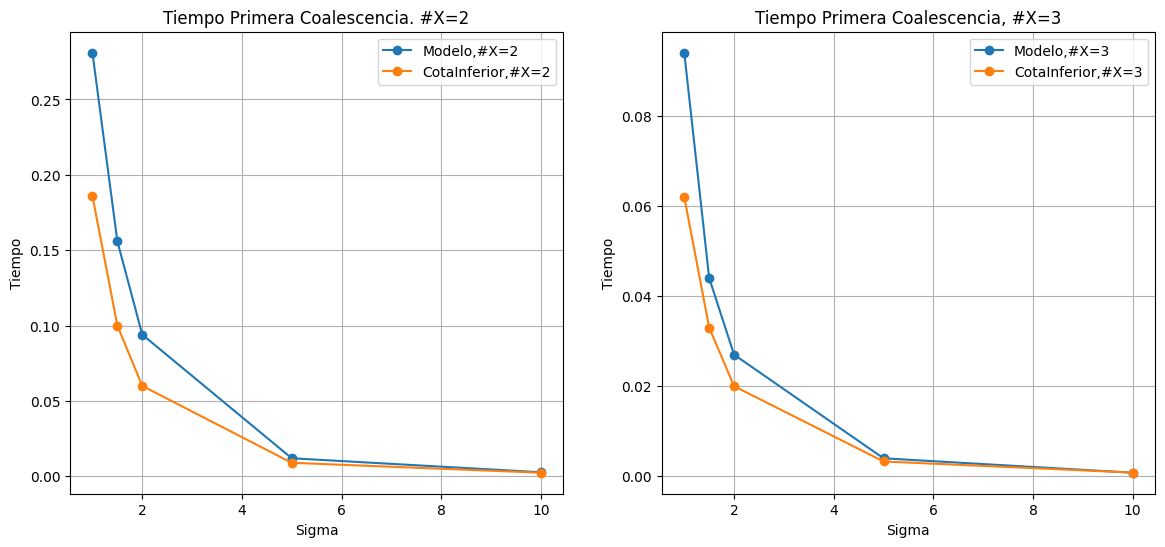

In [ ]:
columna_fija = 'Sigma'

# Definir las columnas variables que quieres graficar para el primer conjunto de datos
columnas_variables_primera = ['Modelo,#X=2', 'CotaInferior,#X=2']

# Definir las columnas variables que quieres graficar para el segundo conjunto de datos
columnas_variables_ultima = ['Modelo,#X=3', 'CotaInferior,#X=3']

# Graficar
plt.figure(figsize=(14, 6))

# Graficar para el primer conjunto de datos
plt.subplot(1, 2, 1)
for col in columnas_variables_primera:
    plt.plot(dfs0[columna_fija], dfs0[col], marker='o', label=col)
plt.title('Tiempo Primera Coalescencia. #X=2')
plt.xlabel('Sigma')
plt.ylabel('Tiempo')
plt.legend()
plt.grid(True)

# Graficar para el segundo conjunto de datos
plt.subplot(1, 2, 2)
for col in columnas_variables_ultima:
    plt.plot(dfs1[columna_fija], dfs1[col], marker='o', label=col)
plt.title('Tiempo Primera Coalescencia, #X=3')
plt.xlabel('Sigma')
plt.ylabel('Tiempo')
plt.legend()
plt.grid(True)

plt.show()


# Simulaciones Extra


In [ ]:
# =========================================================
# EXPERIMENTO 1: listas de unos, variando X y sigma
# (tabla simple: solo tiempos promedio)
# =========================================================

X_values = [2, 3, 5, 10]
sigma_values = [0.0, 0.5, 1.0, 2.0, 5.0, 10.0]   # <-- incluye sigma = 0 siempre
num_sim_e1 = 500

filas_e1 = []

for X in X_values:
    lista_inicial = [1] * X
    for s in sigma_values:
        tiempos_primer = [
            ModeloTiemposPrimer(X, lista_inicial, s, True)
            for _ in range(num_sim_e1)
        ]
        tiempos_ultimo = [
            ModeloTiemposUltimo(X, lista_inicial, s, True)
            for _ in range(num_sim_e1)
        ]

        filas_e1.append({
            "Experimento": "Listas tamaño 1",
            "X": X,
            "Sigma": s,
            "E_primera": np.mean(tiempos_primer),
            "E_ultima": np.mean(tiempos_ultimo)
        })

df_exp1 = pd.DataFrame(filas_e1)

# Tabla global
try:
    df_resultados = pd.concat([df_resultados, df_exp1], ignore_index=True)
except NameError:
    df_resultados = df_exp1.copy()

df_resultados


,Experimento,X,Sigma,E_primera,E_ultima
0,Listas tamaño 1,2,0.0,1.028745,0.995147
1,Listas tamaño 1,2,0.5,0.756838,0.749253
2,Listas tamaño 1,2,1.0,0.632638,0.601996
3,Listas tamaño 1,2,2.0,0.446321,0.463825
4,Listas tamaño 1,2,5.0,0.271393,0.281532
5,Listas tamaño 1,2,10.0,0.169247,0.172765
6,Listas tamaño 1,3,0.0,0.344986,1.305399
7,Listas tamaño 1,3,0.5,0.283124,0.936611
8,Listas tamaño 1,3,1.0,0.255962,0.771816
9,Listas tamaño 1,3,2.0,0.209480,0.513788


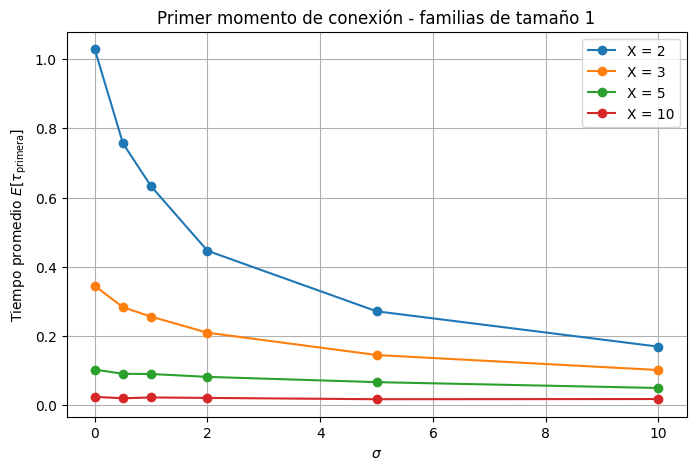

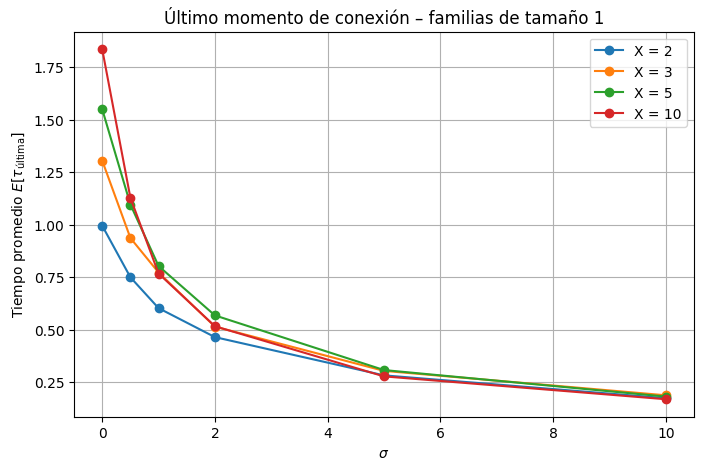

In [ ]:
# =========================================================
# GRÁFICOS EXPERIMENTO 1: E[tiempo] vs sigma para cada X
# =========================================================

df_e1 = df_resultados[df_resultados["Experimento"] == "Listas tamaño 1"]

# Primera conexión
plt.figure(figsize=(8, 5))
for X in sorted(df_e1["X"].unique()):
    sub = df_e1[df_e1["X"] == X]
    plt.plot(sub["Sigma"], sub["E_primera"], marker='o', label=f"X = {X}")

plt.title("Primer momento de conexión - familias de tamaño 1")
plt.xlabel(r"$\sigma$")
plt.ylabel(r"Tiempo promedio $E[\tau_{\text{primera}}]$")
plt.grid(True)
plt.legend()
plt.show()

# Última conexión
plt.figure(figsize=(8, 5))
for X in sorted(df_e1["X"].unique()):
    sub = df_e1[df_e1["X"] == X]
    plt.plot(sub["Sigma"], sub["E_ultima"], marker='o', label=f"X = {X}")

plt.title("Último momento de conexión – familias de tamaño 1")
plt.xlabel(r"$\sigma$")
plt.ylabel(r"Tiempo promedio $E[\tau_{\text{última}}]$")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
# =========================================================
# EXPERIMENTO ASG-DUAL:
# C_i ~ Poisson(2 sigma) condicionado a > 0
# =========================================================

X_values_poisson = [2, 3, 5, 10]
sigma_values_poisson = [0.5, 1.0, 2.0, 5.0]  # usamos σ moderados para evitar bp>1
num_sim_poisson = 500

filas_poisson = []

for X in X_values_poisson:
    for s in sigma_values_poisson:

        # Definimos DistribucionBlo() con lambda = 2*s
        def DistribucionBlo():
            lam = 2 * s
            val = np.random.poisson(lam)
            return val  # la condición >0 la hace tu while(lista[i]<1) en ModeloTiempos*

        configuracion_local = False
        lista_dummy = []

        # Simulaciones
        tiempos_primer = [
            ModeloTiemposPrimer(X, lista_dummy, s, configuracion_local)
            for _ in range(num_sim_poisson)
        ]
        tiempos_ultimo = [
            ModeloTiemposUltimo(X, lista_dummy, s, configuracion_local)
            for _ in range(num_sim_poisson)
        ]

        filas_poisson.append({
            "Experimento": "Poisson(2σ) truncada",
            "X": X,
            "Sigma": s,
            "E_primera": np.mean(tiempos_primer),
            "E_ultima": np.mean(tiempos_ultimo)
        })

df_poisson_asg = pd.DataFrame(filas_poisson)

# Si quieres integrarlo al resumen global:
try:
    df_resultados = pd.concat([df_resultados, df_poisson_asg], ignore_index=True)
except NameError:
    df_resultados = df_poisson_asg.copy()

# Eliminar posibles duplicados por si se reejecuta
df_resultados = df_resultados.drop_duplicates(
    subset=["Experimento", "X", "Sigma"],
    keep="first"
).reset_index(drop=True)

df_poisson_asg


,Experimento,X,Sigma,E_primera,E_ultima
0,Poisson(2σ) truncada,2,0.5,0.598393,0.538109
1,Poisson(2σ) truncada,2,1.0,0.324153,0.291799
2,Poisson(2σ) truncada,2,2.0,0.099207,0.092065
3,Poisson(2σ) truncada,2,5.0,0.011837,0.011988
4,Poisson(2σ) truncada,3,0.5,0.156119,0.620015
5,Poisson(2σ) truncada,3,1.0,0.093377,0.272109
6,Poisson(2σ) truncada,3,2.0,0.029632,0.088458
7,Poisson(2σ) truncada,3,5.0,0.003997,0.010400
8,Poisson(2σ) truncada,5,0.5,0.048369,0.588109
9,Poisson(2σ) truncada,5,1.0,0.024552,0.249515


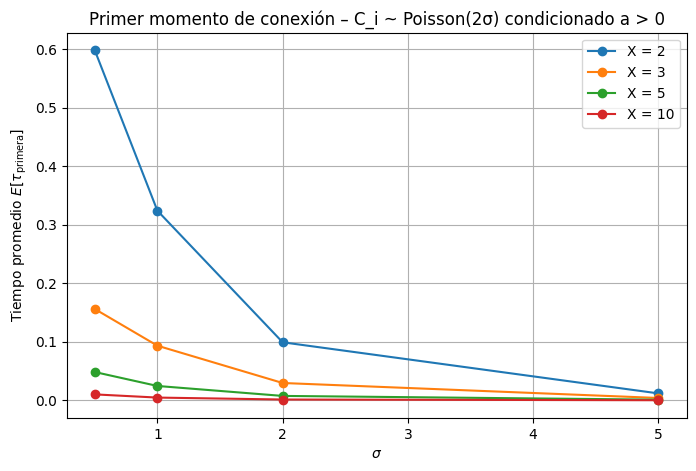

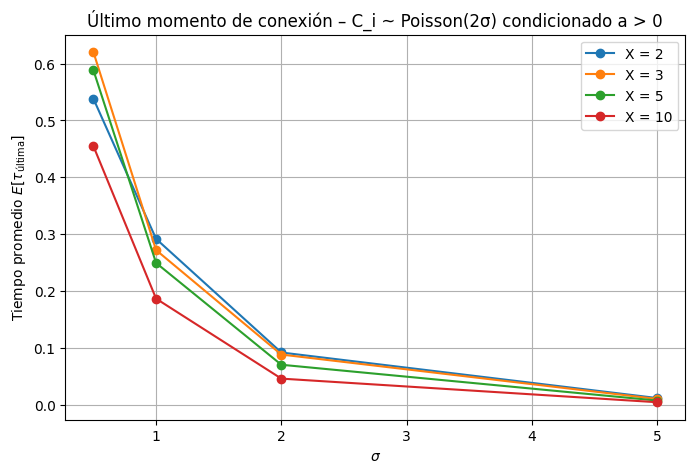

In [ ]:
# =========================================================
# GRÁFICOS EXPERIMENTO ASG-DUAL (Poisson(2σ) truncada)
# =========================================================

df_asg = df_poisson_asg.copy()

# Primer momento de conexión
plt.figure(figsize=(8, 5))
for X in sorted(df_asg["X"].unique()):
    sub = df_asg[df_asg["X"] == X]
    plt.plot(sub["Sigma"], sub["E_primera"], marker='o', label=f"X = {X}")

plt.title("Primer momento de conexión – C_i ~ Poisson(2σ) condicionado a > 0")
plt.xlabel(r"$\sigma$")
plt.ylabel(r"Tiempo promedio $E[\tau_{\text{primera}}]$")
plt.grid(True)
plt.legend()
plt.show()

# Último momento de conexión
plt.figure(figsize=(8, 5))
for X in sorted(df_asg["X"].unique()):
    sub = df_asg[df_asg["X"] == X]
    plt.plot(sub["Sigma"], sub["E_ultima"], marker='o', label=f"X = {X}")

plt.title("Último momento de conexión – C_i ~ Poisson(2σ) condicionado a > 0")
plt.xlabel(r"$\sigma$")
plt.ylabel(r"Tiempo promedio $E[\tau_{\text{última}}]$")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
# =========================================================
# PARTE 3 (Futuro trabajo):
# Configuraciones poco uniformes [1,1,m] con m creciente
# (tabla simple: E_primera y E_ultima)
# =========================================================

sigma_values_m = [0.0, 0.5, 1.0, 2.0, 5.0]      # mismos valores que venías usando
m_values = [1, 2, 3, 5, 10, 20, 30, 50, 100]    # granularidad de m
num_sim_m = 2000

filas_m = []

for m in m_values:
    lista_inicial = [1, 1, m]   # X=3 fijo
    X = len(lista_inicial)

    for s in sigma_values_m:
        tiempos_primer = [
            ModeloTiemposPrimer(X, lista_inicial, s, True)
            for _ in range(num_sim_m)
        ]
        tiempos_ultimo = [
            ModeloTiemposUltimo(X, lista_inicial, s, True)
            for _ in range(num_sim_m)
        ]

        filas_m.append({
            "Experimento": "Poco uniforme [1,1,m]",
            "m": m,
            "X": X,
            "Sigma": s,
            "E_primera": np.mean(tiempos_primer),
            "E_ultima": np.mean(tiempos_ultimo)
        })

df_m = pd.DataFrame(filas_m).sort_values(["m", "Sigma"]).reset_index(drop=True)

# (Opcional) integrar en tu tabla global df_resultados
try:
    df_resultados = pd.concat([df_resultados, df_m[["Experimento","X","Sigma","E_primera","E_ultima"]]], ignore_index=True)
    df_resultados = df_resultados.drop_duplicates(subset=["Experimento","X","Sigma"], keep="first").reset_index(drop=True)
except NameError:
    pass

df_m


,Experimento,m,X,Sigma,E_primera,E_ultima
0,"Poco uniforme [1,1,m]",1,3,0.0,0.330042,1.387410
1,"Poco uniforme [1,1,m]",1,3,0.5,0.289871,0.939143
2,"Poco uniforme [1,1,m]",1,3,1.0,0.249682,0.738801
3,"Poco uniforme [1,1,m]",1,3,2.0,0.210623,0.527907
4,"Poco uniforme [1,1,m]",1,3,5.0,0.144274,0.300208
5,"Poco uniforme [1,1,m]",2,3,0.0,0.224123,0.951336
6,"Poco uniforme [1,1,m]",2,3,0.5,0.188163,0.685613
7,"Poco uniforme [1,1,m]",2,3,1.0,0.178756,0.559748
8,"Poco uniforme [1,1,m]",2,3,2.0,0.149026,0.401812
9,"Poco uniforme [1,1,m]",2,3,5.0,0.108221,0.243028


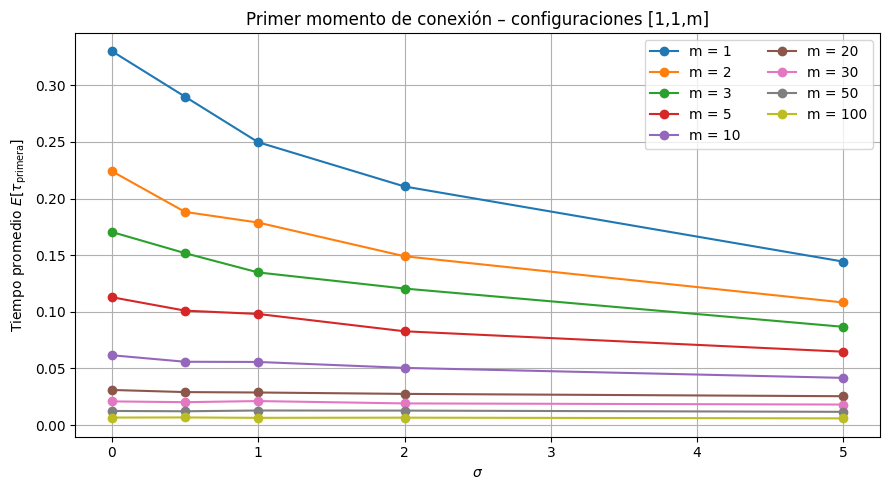

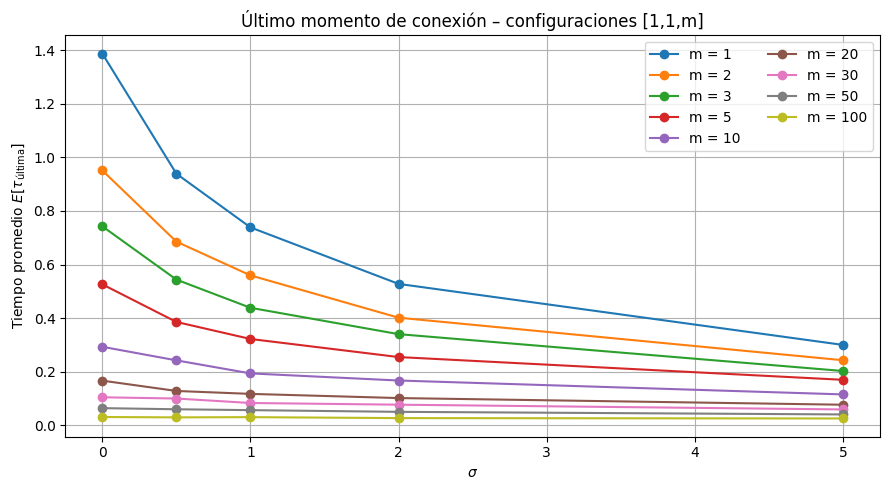

In [ ]:
# =========================================================
# GRÁFICOS PARTE 3: E[tau] vs sigma para cada m
# =========================================================

# Primer momento
plt.figure(figsize=(9, 5))
for m in m_values:
    sub = df_m[df_m["m"] == m]
    plt.plot(sub["Sigma"], sub["E_primera"], marker='o', label=f"m = {m}")

plt.title("Primer momento de conexión – configuraciones [1,1,m]")
plt.xlabel(r"$\sigma$")
plt.ylabel(r"Tiempo promedio $E[\tau_{\text{primera}}]$")
plt.grid(True)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

# Último momento
plt.figure(figsize=(9, 5))
for m in m_values:
    sub = df_m[df_m["m"] == m]
    plt.plot(sub["Sigma"], sub["E_ultima"], marker='o', label=f"m = {m}")

plt.title("Último momento de conexión – configuraciones [1,1,m]")
plt.xlabel(r"$\sigma$")
plt.ylabel(r"Tiempo promedio $E[\tau_{\text{última}}]$")
plt.grid(True)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()



θ = 1  (num_sim=20000)
  mean   = 2.1923
  median = 2.0000
  std    = 2.1596
  P(Δ>0) = 0.7860
  q05    = -1.0000
  q95    = 6.0000


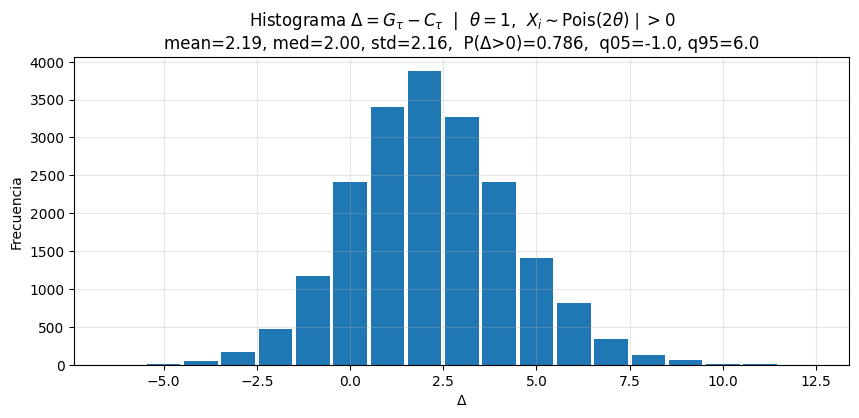


θ = 5  (num_sim=20000)
  mean   = 10.4566
  median = 10.0000
  std    = 5.3658
  P(Δ>0) = 0.9700
  q05    = 2.0000
  q95    = 19.0000


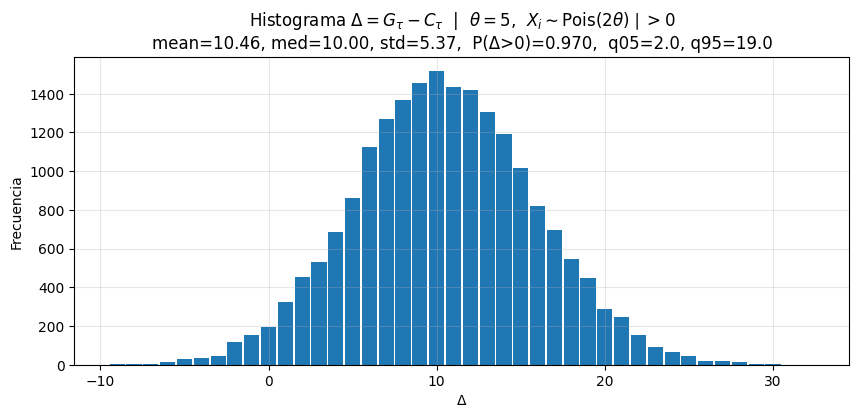


θ = 10  (num_sim=20000)
  mean   = 20.3376
  median = 20.0000
  std    = 7.6992
  P(Δ>0) = 0.9952
  q05    = 8.0000
  q95    = 33.0000


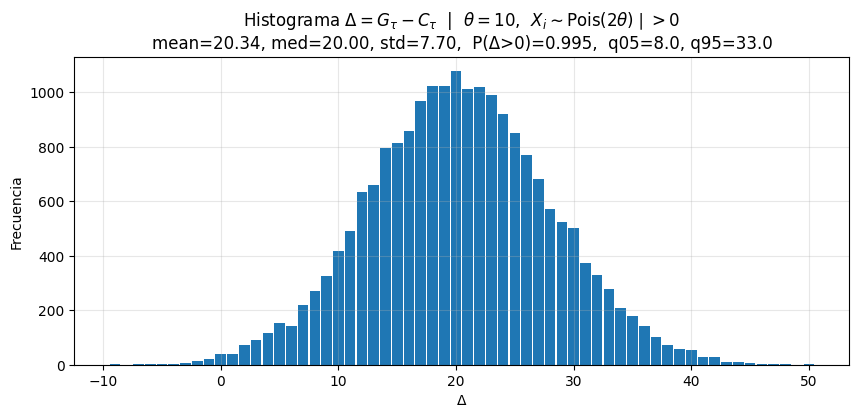


θ = 20  (num_sim=20000)
  mean   = 40.3904
  median = 40.0000
  std    = 10.9610
  P(Δ>0) = 0.9999
  q05    = 22.0000
  q95    = 58.0000


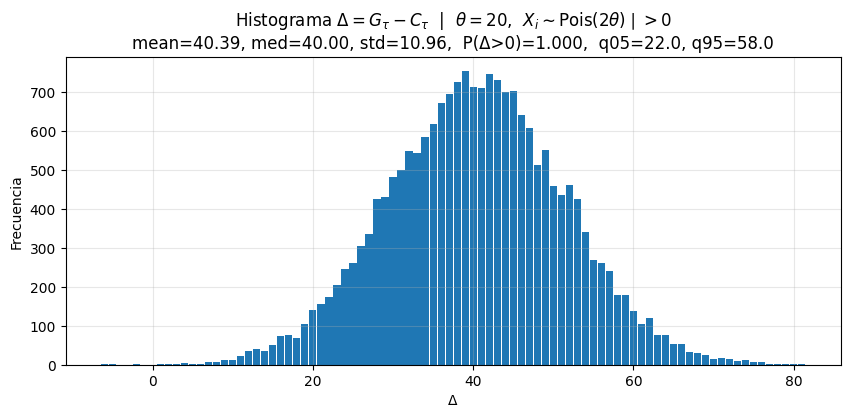

In [ ]:
# =========================================================
# ASG-DUAL (3 BLOQUES) — Experimento sigma-only
# Configuración inicial i.i.d. ~ Poisson(2θ) | >0   (θ = sigma)
# Se simula hasta el primer momento de conexión τ usando TU ModeloHistogramaPrimer.
# Se guarda:
#   G_tau = bloque coalescido en τ
#   C_tau = bloque NO coalescido en τ
# Se grafica SOLO la RESTA (centrada en positivo):
#   Δ = G_tau - C_tau
# Para θ ∈ {1, 5, 10, 20} se generan 4 histogramas + estadísticas.
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
import inspect

# ----------------------------
# Poisson truncada en 0: P(X=k | X>0)
# ----------------------------
def ztrunc_poisson(lam: float, size: int, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    out = np.empty(size, dtype=int)
    filled = 0
    while filled < size:
        draw = rng.poisson(lam, size=(size - filled))
        draw = draw[draw > 0]
        take = min(len(draw), size - filled)
        if take > 0:
            out[filled:filled+take] = draw[:take]
            filled += take
    return out

# ----------------------------
# Llamada robusta a tu ModeloHistogramaPrimer (sin keywords)
# ----------------------------
def call_ModeloHistogramaPrimer(tamano_lista, lista_inicial, sigma, configuracion):
    try:
        return ModeloHistogramaPrimer(tamano_lista, lista_inicial, sigma, configuracion)
    except TypeError:
        pass
    try:
        return ModeloHistogramaPrimer(lista_inicial, sigma, configuracion)
    except TypeError:
        pass
    try:
        return ModeloHistogramaPrimer(lista_inicial, tamano_lista, sigma, configuracion)
    except TypeError:
        pass

    sig = inspect.signature(ModeloHistogramaPrimer)
    raise TypeError(f"No pude calzar la firma de ModeloHistogramaPrimer. Firma detectada: {sig}")

# ----------------------------
# Simulación principal (devuelve Δ = G_tau - C_tau)
# ----------------------------
def sim_delta_pos(theta: float, num_sim: int = 20000, seed: int | None = 123):
    rng = np.random.default_rng(seed)
    lam = 2.0 * theta  # Poisson(2θ) | >0

    delta_pos = np.empty(num_sim, dtype=float)

    for k in range(num_sim):
        a, b, c = ztrunc_poisson(lam, 3, rng=rng)
        lista_inicial = [int(a), int(b), int(c)]

        lista_post, i, j = call_ModeloHistogramaPrimer(0, lista_inicial, theta, True)

        idx_coal = min(i, j)
        g = lista_post[idx_coal]  # coalesció
        c_no = [lista_post[t] for t in range(len(lista_post)) if t != idx_coal][0]  # no coalesció

        delta_pos[k] = g - c_no   # Δ = G_tau - C_tau  (típicamente positivo)

    return delta_pos

# ----------------------------
# Resumen estadístico compacto (para imprimir)
# ----------------------------
def resumen_stats(x: np.ndarray):
    x = np.asarray(x)
    return {
        "mean": float(np.mean(x)),
        "median": float(np.median(x)),
        "std": float(np.std(x)),
        "p_gt_0": float(np.mean(x > 0)),
        "q05": float(np.quantile(x, 0.05)),
        "q95": float(np.quantile(x, 0.95)),
    }

# ----------------------------
# CORRER PARA θ = 1,5,10,20 Y GRAFICAR 4 HISTOGRAMAS
# ----------------------------
thetas = [1, 5, 10, 20]
num_sim = 20000
base_seed = 123  # fijo para reproducibilidad

for idx, theta in enumerate(thetas):
    delta_pos = sim_delta_pos(theta=theta, num_sim=num_sim, seed=base_seed + idx)

    st = resumen_stats(delta_pos)
    print(f"\nθ = {theta}  (num_sim={num_sim})")
    print(f"  mean   = {st['mean']:.4f}")
    print(f"  median = {st['median']:.4f}")
    print(f"  std    = {st['std']:.4f}")
    print(f"  P(Δ>0) = {st['p_gt_0']:.4f}")
    print(f"  q05    = {st['q05']:.4f}")
    print(f"  q95    = {st['q95']:.4f}")

    # Histograma discreto (bins enteros centrados)
    bins = np.arange(delta_pos.min() - 0.5, delta_pos.max() + 1.5, 1)

    plt.figure(figsize=(10,4))
    plt.hist(delta_pos, bins=bins, rwidth=0.9)
    plt.title(
        rf"Histograma $\Delta=G_\tau-C_\tau$  |  $\theta={theta}$,  $X_i\sim \mathrm{{Pois}}(2\theta)\mid>0$"
        + "\n"
        + rf"mean={st['mean']:.2f}, med={st['median']:.2f}, std={st['std']:.2f},  P(Δ>0)={st['p_gt_0']:.3f},  q05={st['q05']:.1f}, q95={st['q95']:.1f}"
    )
    plt.xlabel(r"$\Delta$")
    plt.ylabel("Frecuencia")
    plt.grid(True, alpha=0.3)
    plt.show()

    # (Opcional) si quieres además tu analyze_data:
    # analyze_data(delta_pos, rf"$\Delta=G_\tau-C_\tau$ (θ={theta})")


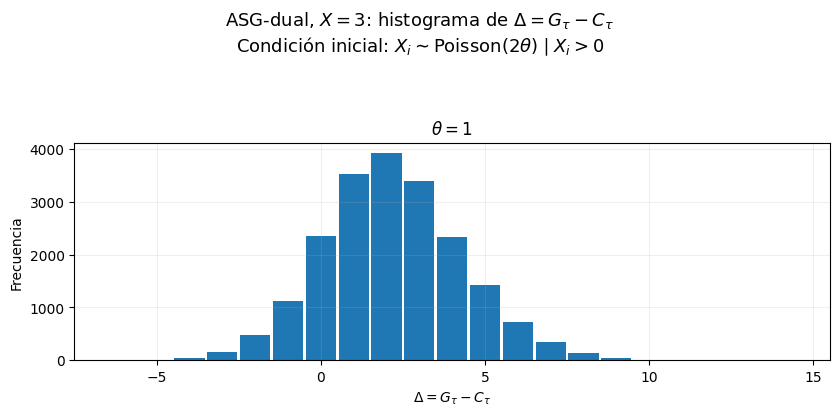

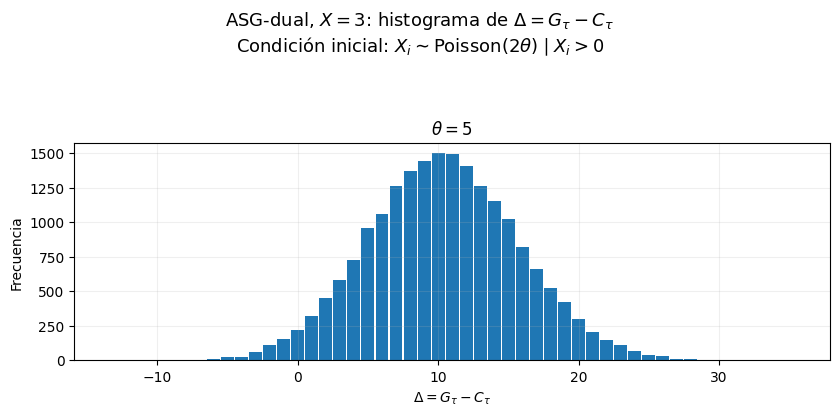

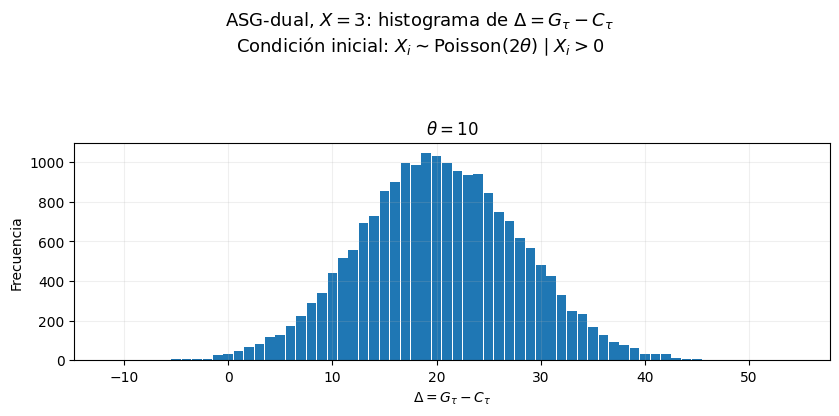

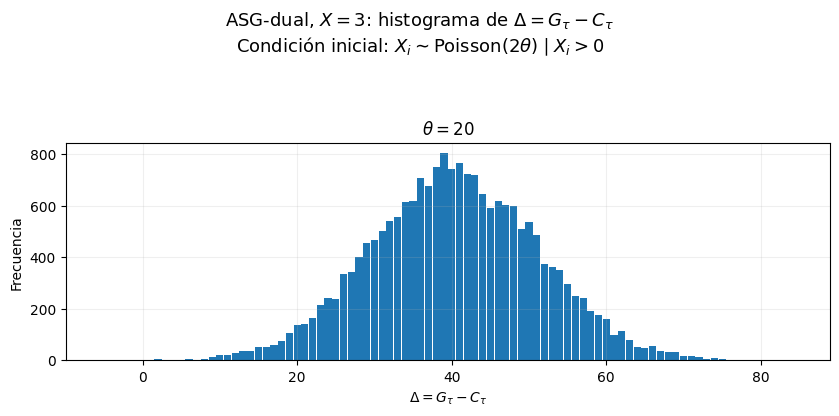

Guardadas individuales: ['G-C_1.png', 'G-C_2.png', 'G-C_3.png', 'G-C_4.png']


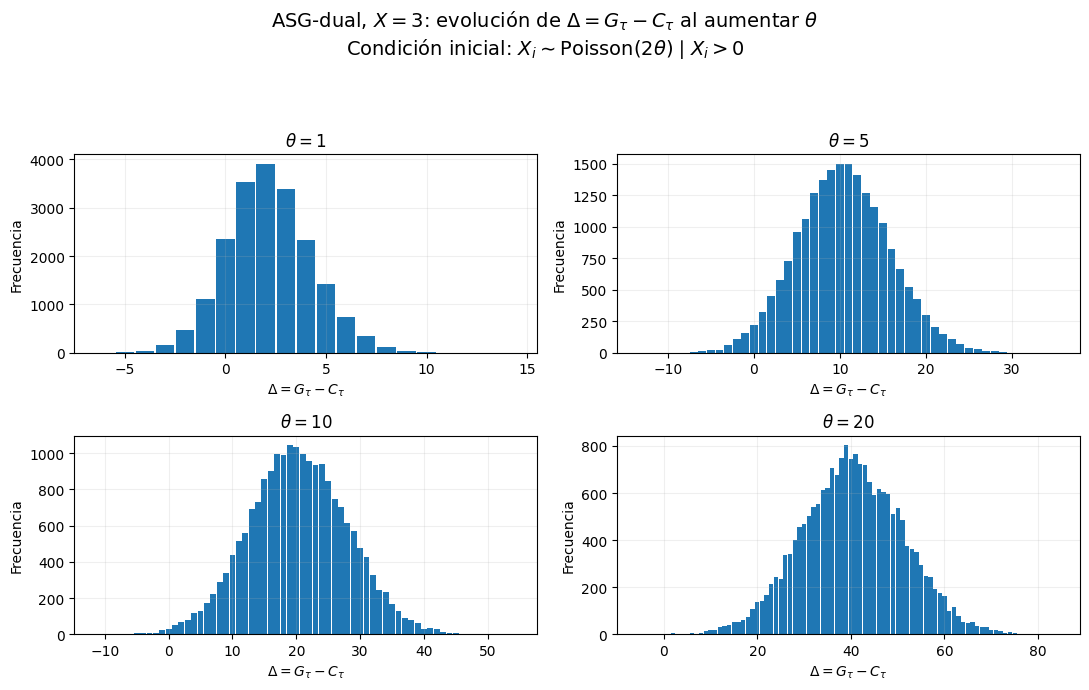

Guardada figura combinada: G-C_grid.png


In [ ]:
# =========================================================
# ASG-DUAL (3 BLOQUES) — Figuras para tesis
# Δ = G_τ - C_τ, con condición inicial Xi ~ Poisson(2θ) | Xi>0
# Guarda 4 figuras individuales: G-C_1.png ... G-C_4.png
# Guarda 1 figura 2x2: G-C_grid.png
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
import inspect

# ----------------------------
# Poisson truncada en 0: P(X=k | X>0)
# ----------------------------
def ztrunc_poisson(lam: float, size: int, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    out = np.empty(size, dtype=int)
    filled = 0
    while filled < size:
        draw = rng.poisson(lam, size=(size - filled))
        draw = draw[draw > 0]
        take = min(len(draw), size - filled)
        if take > 0:
            out[filled:filled+take] = draw[:take]
            filled += take
    return out

# ----------------------------
# Llamada robusta a tu ModeloHistogramaPrimer (sin keywords)
# ----------------------------
def call_ModeloHistogramaPrimer(tamano_lista, lista_inicial, sigma, configuracion):
    try:
        return ModeloHistogramaPrimer(tamano_lista, lista_inicial, sigma, configuracion)
    except TypeError:
        pass
    try:
        return ModeloHistogramaPrimer(lista_inicial, sigma, configuracion)
    except TypeError:
        pass
    try:
        return ModeloHistogramaPrimer(lista_inicial, tamano_lista, sigma, configuracion)
    except TypeError:
        pass

    sig = inspect.signature(ModeloHistogramaPrimer)
    raise TypeError(f"No pude calzar la firma de ModeloHistogramaPrimer. Firma detectada: {sig}")

# ----------------------------
# Simulación principal: Δ = G_τ - C_τ
# ----------------------------
def sim_delta_pos(theta: float, num_sim: int = 20000, seed: int = 123):
    rng = np.random.default_rng(seed)
    lam = 2.0 * theta  # Poisson(2θ) | >0

    delta_pos = np.empty(num_sim, dtype=float)

    for k in range(num_sim):
        a, b, c = ztrunc_poisson(lam, 3, rng=rng)
        lista_inicial = [int(a), int(b), int(c)]

        lista_post, i, j = call_ModeloHistogramaPrimer(0, lista_inicial, theta, True)

        idx_coal = min(i, j)
        g = float(lista_post[idx_coal])  # coalesció
        c_no = float([lista_post[t] for t in range(len(lista_post)) if t != idx_coal][0])  # no coalesció

        delta_pos[k] = g - c_no

    return delta_pos

# ----------------------------
# Función de dibujo (reutilizable)
# ----------------------------
def draw_hist(ax, delta_pos, theta):
    bins = np.arange(delta_pos.min() - 0.5, delta_pos.max() + 1.5, 1)
    ax.hist(delta_pos, bins=bins, rwidth=0.92)
    ax.set_title(rf"$\theta={theta}$", fontsize=12)
    ax.set_xlabel(r"$\Delta = G_\tau - C_\tau$")
    ax.set_ylabel("Frecuencia")
    ax.grid(True, alpha=0.20)

# ----------------------------
# Parámetros
# ----------------------------
thetas = [1, 5, 10, 20]
num_sim = 20000
base_seed = 123

# ----------------------------
# 1) Generar y guardar 4 figuras individuales
# ----------------------------
all_deltas = []  # para la figura 2x2

for i, theta in enumerate(thetas, start=1):
    delta_pos = sim_delta_pos(theta=theta, num_sim=num_sim, seed=base_seed + i)
    all_deltas.append((theta, delta_pos))

    fig, ax = plt.subplots(figsize=(8.5, 4.2))
    draw_hist(ax, delta_pos, theta)

    # Título general simple (2 líneas)
    fig.suptitle(
        r"ASG-dual, $X=3$: histograma de $\Delta = G_\tau - C_\tau$" + "\n" +
        r"Condición inicial: $X_i\sim \mathrm{Poisson}(2\theta)\mid X_i>0$",
        fontsize=13
    )

    fig.tight_layout(rect=[0, 0, 1, 0.90])
    outname = f"G-C_{i}.png"
    fig.savefig(outname, dpi=300, bbox_inches="tight")
    plt.show()

print("Guardadas individuales:", [f"G-C_{i}.png" for i in range(1, 5)])

# ----------------------------
# 2) Figura 2x2 combinada (evolución con θ)
# ----------------------------
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharey=False)
axes = axes.ravel()

for ax, (theta, delta_pos) in zip(axes, all_deltas):
    draw_hist(ax, delta_pos, theta)

fig.suptitle(
    r"ASG-dual, $X=3$: evolución de $\Delta = G_\tau - C_\tau$ al aumentar $\theta$" + "\n" +
    r"Condición inicial: $X_i\sim \mathrm{Poisson}(2\theta)\mid X_i>0$",
    fontsize=14
)

fig.tight_layout(rect=[0, 0, 1, 0.92])
fig.savefig("G-C_grid.png", dpi=300, bbox_inches="tight")
plt.show()

print("Guardada figura combinada: G-C_grid.png")


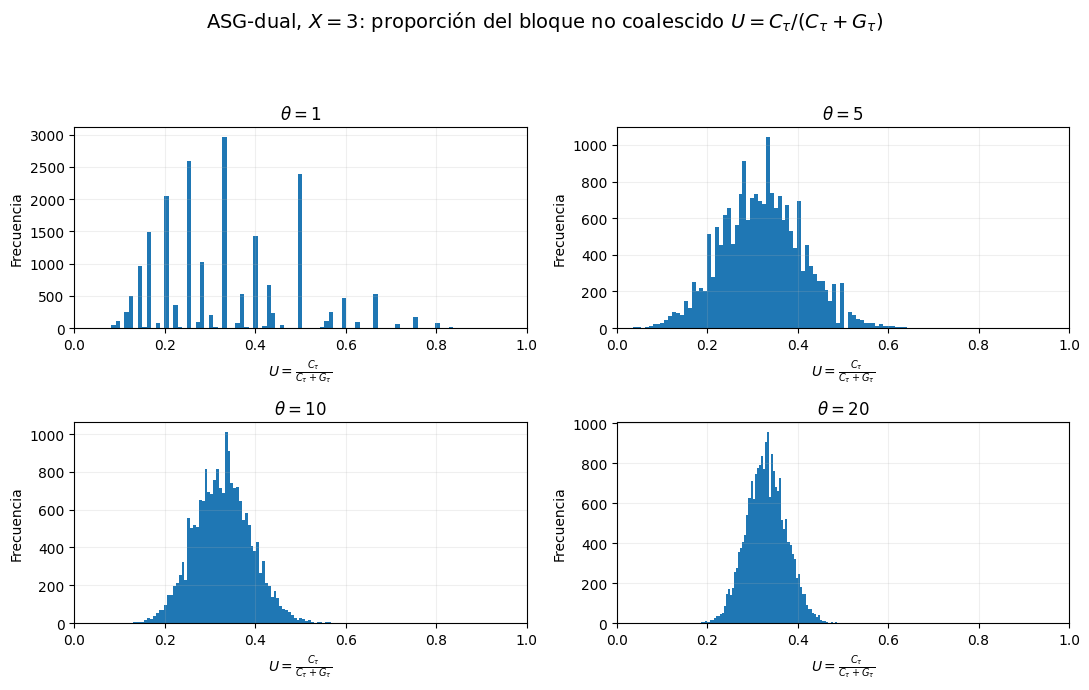

Guardada: U_grid.png


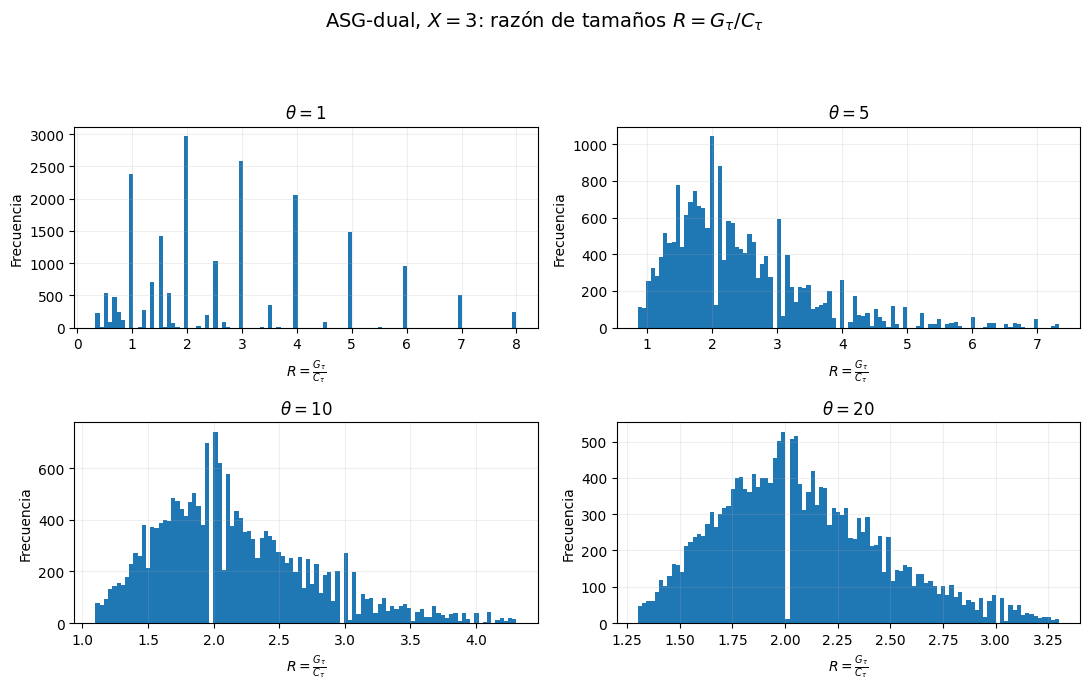

Guardada: R_grid.png


In [ ]:
# =========================================================
# ASG-DUAL (3 BLOQUES) — Experimentos exploratorios (para tesis)
# Condición inicial: Xi ~ Poisson(2θ) | Xi>0, i.i.d. (θ = sigma)
# Primer momento de conexión τ usando TU ModeloHistogramaPrimer
#
# Variables:
#   (Opción 2) U = C_τ / (C_τ + G_τ)   en (0,1)
#   (Opción 3) R = G_τ / C_τ           (típicamente > 1)
#
# Produce 2 figuras 2x2 (una para U y otra para R) para θ ∈ {1,5,10,20}
# Guarda:
#   U_grid.png   y   R_grid.png
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
import inspect

# ----------------------------
# Poisson truncada en 0: P(X=k | X>0)
# ----------------------------
def ztrunc_poisson(lam: float, size: int, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    out = np.empty(size, dtype=int)
    filled = 0
    while filled < size:
        draw = rng.poisson(lam, size=(size - filled))
        draw = draw[draw > 0]
        take = min(len(draw), size - filled)
        if take > 0:
            out[filled:filled+take] = draw[:take]
            filled += take
    return out

# ----------------------------
# Llamada robusta a tu ModeloHistogramaPrimer (sin keywords)
# ----------------------------
def call_ModeloHistogramaPrimer(tamano_lista, lista_inicial, sigma, configuracion):
    try:
        return ModeloHistogramaPrimer(tamano_lista, lista_inicial, sigma, configuracion)
    except TypeError:
        pass
    try:
        return ModeloHistogramaPrimer(lista_inicial, sigma, configuracion)
    except TypeError:
        pass
    try:
        return ModeloHistogramaPrimer(lista_inicial, tamano_lista, sigma, configuracion)
    except TypeError:
        pass

    sig = inspect.signature(ModeloHistogramaPrimer)
    raise TypeError(f"No pude calzar la firma de ModeloHistogramaPrimer. Firma detectada: {sig}")

# ----------------------------
# Simulación: devuelve arrays U y R para un theta dado (X=3)
# ----------------------------
def sim_U_R(theta: float, num_sim: int = 20000, seed: int = 123):
    rng = np.random.default_rng(seed)
    lam = 2.0 * theta

    U = np.empty(num_sim, dtype=float)
    R = np.empty(num_sim, dtype=float)

    for k in range(num_sim):
        a, b, c = ztrunc_poisson(lam, 3, rng=rng)
        init = [int(a), int(b), int(c)]

        lista_post, i, j = call_ModeloHistogramaPrimer(0, init, theta, True)

        idx_coal = min(i, j)
        g = float(lista_post[idx_coal])  # G_tau
        c_no = float([lista_post[t] for t in range(len(lista_post)) if t != idx_coal][0])  # C_tau

        U[k] = c_no / (c_no + g)         # Opción 2
        R[k] = g / c_no                  # Opción 3

    return U, R

# ----------------------------
# Plot grid 2x2 (limpio para tesis) para una variable
# ----------------------------
def plot_grid_variable(var_list, thetas, var_name, xlabel, suptitle, outname,
                       bins=80, xlim=None, use_quantile_clip=False, q=(0.01, 0.99)):
    fig, axes = plt.subplots(2, 2, figsize=(11, 7))
    axes = axes.ravel()

    for ax, theta, data in zip(axes, thetas, var_list):
        x = data

        # opcional: recortar colas para ver mejor la masa
        if use_quantile_clip:
            lo, hi = np.quantile(x, q)
            x = x[(x >= lo) & (x <= hi)]

        ax.hist(x, bins=bins)
        ax.set_title(rf"$\theta={theta}$", fontsize=12)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Frecuencia")
        ax.grid(True, alpha=0.20)
        if xlim is not None:
            ax.set_xlim(xlim)

    fig.suptitle(suptitle, fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.92])
    fig.savefig(outname, dpi=300, bbox_inches="tight")
    plt.show()
    print("Guardada:", outname)

# ----------------------------
# EJECUCIÓN (θ = 1,5,10,20)
# ----------------------------
thetas = [1, 5, 10, 20]
num_sim = 20000
base_seed = 123

U_list = []
R_list = []

for idx, theta in enumerate(thetas):
    U, R = sim_U_R(theta=theta, num_sim=num_sim, seed=base_seed + idx)
    U_list.append(U)
    R_list.append(R)

# ----------------------------
# FIGURA 1: U = C/(C+G)
# (acotada en (0,1), no necesita recorte)
# ----------------------------
plot_grid_variable(
    var_list=U_list,
    thetas=thetas,
    var_name="U",
    xlabel=r"$U = \frac{C_\tau}{C_\tau+G_\tau}$",
    suptitle=r"ASG-dual, $X=3$: proporción del bloque no coalescido $U=C_\tau/(C_\tau+G_\tau)$",
    outname="U_grid.png",
    bins=80,
    xlim=(0, 1),
    use_quantile_clip=False
)

# ----------------------------
# FIGURA 2: R = G/C
# (puede tener cola; usamos zoom 1%–99% para que se vea bien)
# ----------------------------
plot_grid_variable(
    var_list=R_list,
    thetas=thetas,
    var_name="R",
    xlabel=r"$R = \frac{G_\tau}{C_\tau}$",
    suptitle=r"ASG-dual, $X=3$: razón de tamaños $R=G_\tau/C_\tau$",
    outname="R_grid.png",
    bins=100,
    xlim=None,
    use_quantile_clip=True,
    q=(0.01, 0.99)
)



θ=1
  mean(U)   = 0.3295421877537667
  median(U) = 0.3333333333333333
  P(U<0.5)  = 0.79105


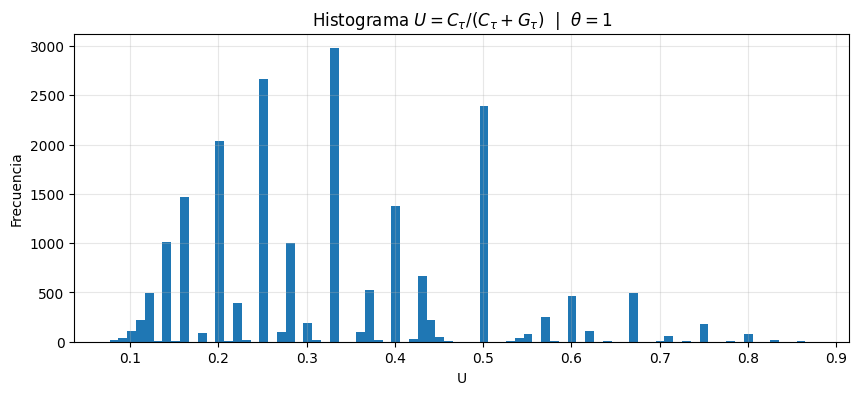


θ=5
  mean(U)   = 0.32037248203927676
  median(U) = 0.32
  P(U<0.5)  = 0.96705


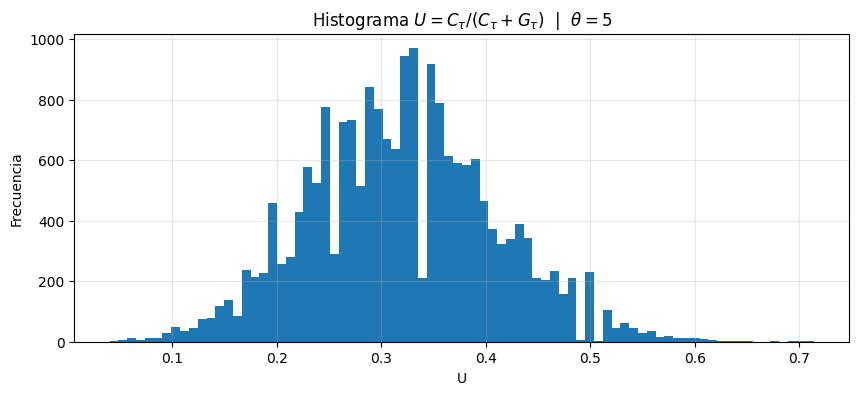


θ=10
  mean(U)   = 0.3276523269713129
  median(U) = 0.32727272727272727
  P(U<0.5)  = 0.99515


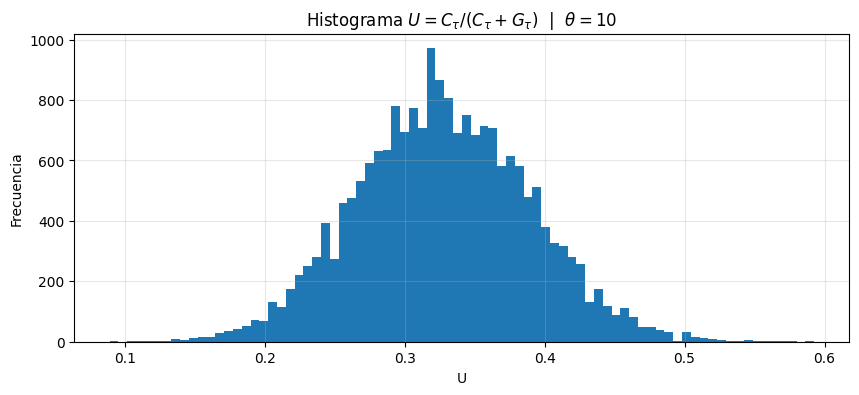


θ=20
  mean(U)   = 0.3304835331579823
  median(U) = 0.33035714285714285
  P(U<0.5)  = 0.99995


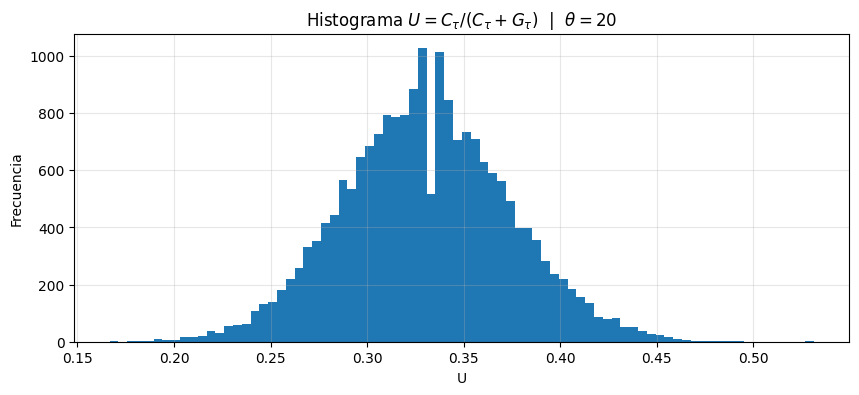

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import inspect

def ztrunc_poisson(lam: float, size: int, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    out = np.empty(size, dtype=int)
    filled = 0
    while filled < size:
        draw = rng.poisson(lam, size=(size - filled))
        draw = draw[draw > 0]
        take = min(len(draw), size - filled)
        if take > 0:
            out[filled:filled+take] = draw[:take]
            filled += take
    return out

def call_ModeloHistogramaPrimer(tamano_lista, lista_inicial, sigma, configuracion):
    try:
        return ModeloHistogramaPrimer(tamano_lista, lista_inicial, sigma, configuracion)
    except TypeError:
        pass
    try:
        return ModeloHistogramaPrimer(lista_inicial, sigma, configuracion)
    except TypeError:
        pass
    try:
        return ModeloHistogramaPrimer(lista_inicial, tamano_lista, sigma, configuracion)
    except TypeError:
        pass
    sig = inspect.signature(ModeloHistogramaPrimer)
    raise TypeError(f"No pude calzar la firma de ModeloHistogramaPrimer. Firma detectada: {sig}")

def sim_U(theta: float, num_sim: int = 20000, seed: int = 123):
    rng = np.random.default_rng(seed)
    lam = 2.0 * theta

    U = np.empty(num_sim, dtype=float)

    for k in range(num_sim):
        a, b, c = ztrunc_poisson(lam, 3, rng=rng)
        lista_inicial = [int(a), int(b), int(c)]

        lista_post, i, j = call_ModeloHistogramaPrimer(0, lista_inicial, theta, True)

        idx_coal = min(i, j)
        g = float(lista_post[idx_coal])
        c_no = float([lista_post[t] for t in range(len(lista_post)) if t != idx_coal][0])

        U[k] = c_no / (c_no + g)

    return U

thetas = [1, 5, 10, 20]
num_sim = 20000
base_seed = 123

for idx, theta in enumerate(thetas):
    U = sim_U(theta, num_sim=num_sim, seed=base_seed + idx)

    print(f"\nθ={theta}")
    print("  mean(U)   =", U.mean())
    print("  median(U) =", np.median(U))
    print("  P(U<0.5)  =", np.mean(U < 0.5))

    plt.figure(figsize=(10,4))
    plt.hist(U, bins=80)
    plt.title(rf"Histograma $U=C_\tau/(C_\tau+G_\tau)$  |  $\theta={theta}$")
    plt.xlabel("U")
    plt.ylabel("Frecuencia")
    plt.grid(True, alpha=0.3)
    plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

delta = np.array(C_tau) - np.array(G_tau)

bins = np.arange(delta.min() - 0.5, delta.max() + 1.5, 1)  # ancho 1, centrado en enteros

plt.figure(figsize=(10,4))
plt.hist(delta, bins=bins, rwidth=0.9)
plt.title(r"Histograma de $C_\tau - G_\tau$ (bins enteros)")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.grid(True, alpha=0.3)
plt.show()


NameError: name 'C_tau' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import inspect

# ----------------------------
# Poisson truncada en 0: P(X=k | X>0)
# ----------------------------
def ztrunc_poisson(lam: float, size: int, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    out = np.empty(size, dtype=int)
    filled = 0
    while filled < size:
        draw = rng.poisson(lam, size=(size - filled))
        draw = draw[draw > 0]
        take = min(len(draw), size - filled)
        if take > 0:
            out[filled:filled+take] = draw[:take]
            filled += take
    return out

# ----------------------------
# Llamada robusta a tu ModeloHistogramaPrimer
# (evita keywords y prueba órdenes típicos)
# ----------------------------
def call_ModeloHistogramaPrimer(tamano_lista, lista_inicial, sigma, configuracion):
    # 1) el orden que ya venías usando: (tamano_lista, lista_inicial, sigma, configuracion)
    try:
        return ModeloHistogramaPrimer(tamano_lista, lista_inicial, sigma, configuracion)
    except TypeError:
        pass

    # 2) si tu firma es (lista_inicial, sigma, configuracion) o similar
    try:
        return ModeloHistogramaPrimer(lista_inicial, sigma, configuracion)
    except TypeError:
        pass

    # 3) si tu firma es (lista_inicial, tamano_lista, sigma, configuracion)
    try:
        return ModeloHistogramaPrimer(lista_inicial, tamano_lista, sigma, configuracion)
    except TypeError:
        pass

    # Si ninguna cuadra, imprime la firma real para que la ajustes 1 vez
    sig = inspect.signature(ModeloHistogramaPrimer)
    raise TypeError(f"No pude calzar la firma de ModeloHistogramaPrimer. Firma detectada: {sig}")

# ----------------------------
# EXPERIMENTO: ASG-dual 3 bloques
# Solo configuras sigma y num_sim
# ----------------------------
def experimento_asg_dual_3bloques_trunc_poisson(sigma: float, num_sim: int = 10000, seed: int | None = None):
    rng = np.random.default_rng(seed)
    lam = 2.0 * sigma  # Poisson(2σ) | >0

    G_tau, C_tau, delta, inits = [], [], [], []

    for _ in range(num_sim):
        a, b, c = ztrunc_poisson(lam, 3, rng=rng)
        lista_inicial = [int(a), int(b), int(c)]
        inits.append(lista_inicial)

        lista_post, i, j = call_ModeloHistogramaPrimer(0, lista_inicial, sigma, True)

        idx_coal = min(i, j)              # donde queda el bloque coalescido en tu implementación
        g = lista_post[idx_coal]          # G_tau
        c_no = [lista_post[t] for t in range(len(lista_post)) if t != idx_coal][0]  # C_tau

        G_tau.append(g)
        C_tau.append(c_no)
        delta.append(c_no - g)            # RESTA: C_tau - G_tau

    return np.array(G_tau), np.array(C_tau), np.array(delta), np.array(inits)

# ----------------------------
# CORRER + GRAFICAR (detallado para variable discreta)
# ----------------------------
sigma = 1.0
num_sim = 20000

G_tau, C_tau, delta, inits = experimento_asg_dual_3bloques_trunc_poisson(sigma=sigma, num_sim=num_sim, seed=123)

print("Ejemplos de configuraciones iniciales:", inits[:5])
analyze_data(delta, r"$C_\tau - G_\tau$")

# Histograma “bonito” para enteros: bins centrados en enteros
bins = np.arange(delta.min() - 0.5, delta.max() + 1.5, 1)

plt.figure(figsize=(10,4))
plt.hist(delta, bins=bins, rwidth=0.9)
plt.title(r"Histograma detallado de $C_\tau - G_\tau$ (Poisson(2$\sigma$)|>0, 3 bloques)")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.grid(True, alpha=0.3)
plt.show()

# (Opcional) barras exactas por valor (PMF empírica)
vals, counts = np.unique(delta, return_counts=True)
plt.figure(figsize=(10,4))
plt.bar(vals, counts)
plt.title(r"Frecuencia exacta de $C_\tau - G_\tau$")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.grid(True, alpha=0.3)
plt.show()


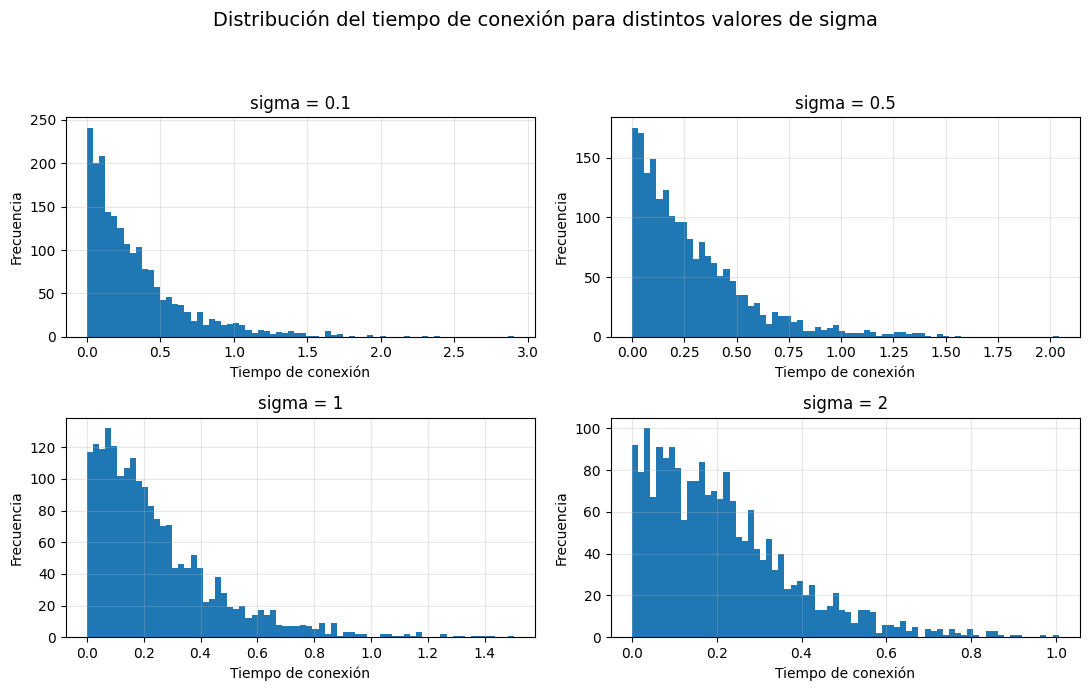

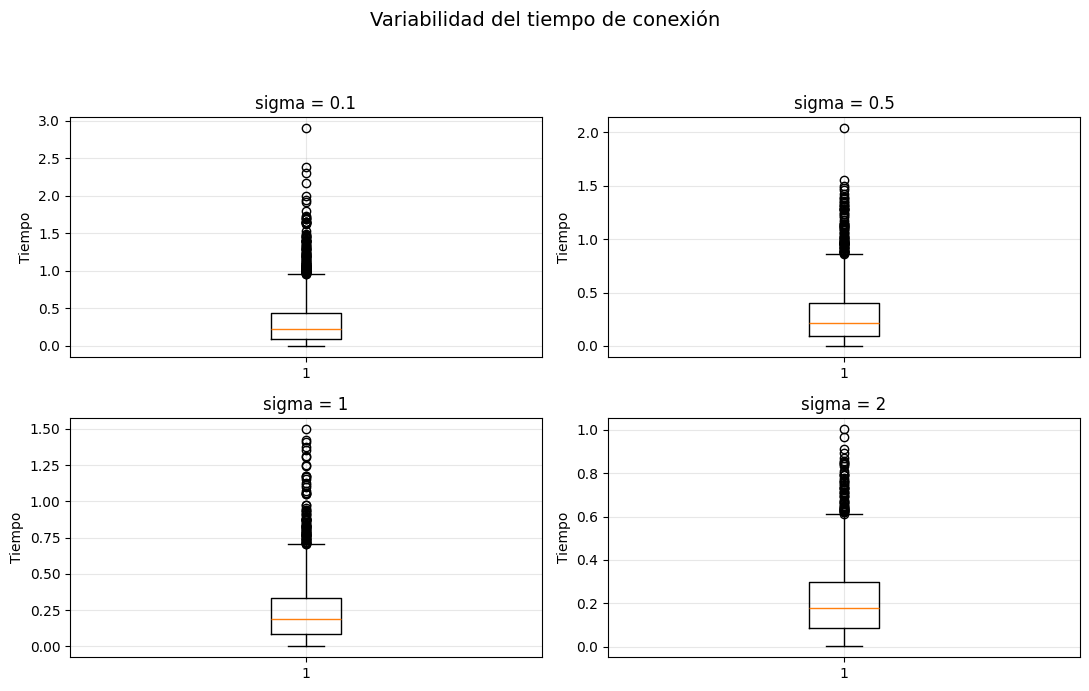

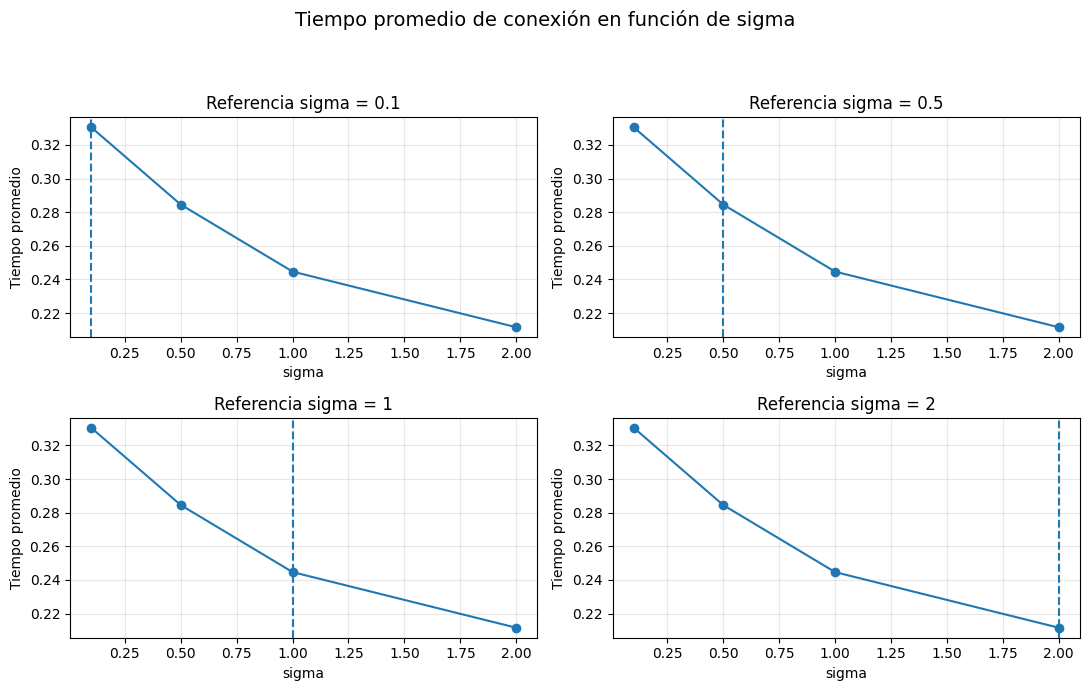

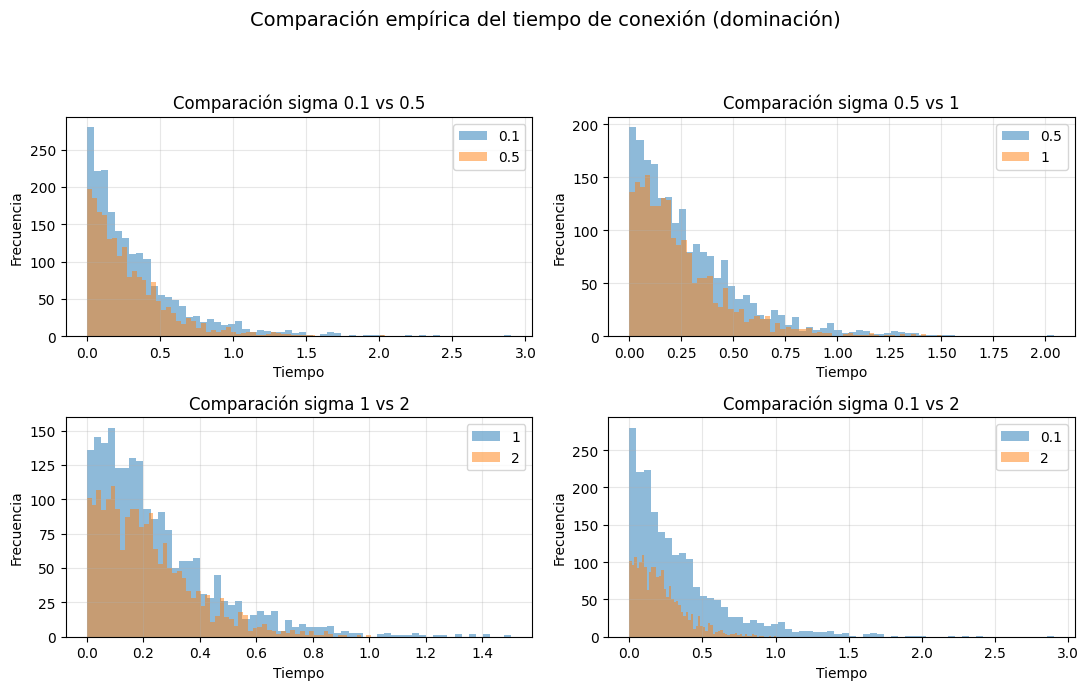

In [ ]:
# =========================================================
# 🔥 FIGURAS 2x2 — ANÁLISIS EXPLORATORIO COMPLETO (TESIS)
# Usa ModeloTiemposPrimer
# =========================================================

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Simulación base
# -----------------------------
def sim_tiempos(tamano_lista, lista, sigma, n_sim=200):
    tiempos = []
    for _ in range(n_sim):
        t = ModeloTiemposPrimer(tamano_lista, lista, sigma, True)
        tiempos.append(t)
    return np.array(tiempos)


# -----------------------------
# Parámetros
# -----------------------------
sigmas = [0.1, 0.5, 1, 2]
tamano_lista = 3
lista = [1,1,1]
n_sim = 2000

# Simular datos
data = {sigma: sim_tiempos(tamano_lista, lista, sigma, n_sim) for sigma in sigmas}


# =========================================================
# ⭐ FIGURA 1: HISTOGRAMAS (uno por sigma)
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(11,7))
axes = axes.ravel()

for ax, sigma in zip(axes, sigmas):
    ax.hist(data[sigma], bins=70)
    ax.set_title(f"sigma = {sigma}")
    ax.set_xlabel("Tiempo de conexión")
    ax.set_ylabel("Frecuencia")
    ax.grid(alpha=0.3)

fig.suptitle("Distribución del tiempo de conexión para distintos valores de sigma", fontsize=14)
fig.tight_layout(rect=[0,0,1,0.93])
plt.show()


# =========================================================
# ⭐ FIGURA 2: BOXPLOTS (uno por sigma en cada panel)
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(11,7))
axes = axes.ravel()

for ax, sigma in zip(axes, sigmas):
    ax.boxplot(data[sigma])
    ax.set_title(f"sigma = {sigma}")
    ax.set_ylabel("Tiempo")
    ax.grid(alpha=0.3)

fig.suptitle("Variabilidad del tiempo de conexión", fontsize=14)
fig.tight_layout(rect=[0,0,1,0.93])
plt.show()


# =========================================================
# ⭐ FIGURA 3: PROMEDIO vs sigma (repetido para consistencia visual)
# =========================================================
promedios = [np.mean(data[s]) for s in sigmas]

fig, axes = plt.subplots(2, 2, figsize=(11,7))
axes = axes.ravel()

for ax, sigma, prom in zip(axes, sigmas, promedios):
    ax.plot(sigmas, promedios, marker='o')
    ax.axvline(sigma, linestyle='--')
    ax.set_title(f"Referencia sigma = {sigma}")
    ax.set_xlabel("sigma")
    ax.set_ylabel("Tiempo promedio")
    ax.grid(alpha=0.3)

fig.suptitle("Tiempo promedio de conexión en función de sigma", fontsize=14)
fig.tight_layout(rect=[0,0,1,0.93])
plt.show()


# =========================================================
# ⭐ FIGURA 4: DOMINACIÓN (pares de sigma)
# =========================================================
pairs = [(0.1,0.5), (0.5,1), (1,2), (0.1,2)]

fig, axes = plt.subplots(2, 2, figsize=(11,7))
axes = axes.ravel()

for ax, (s1, s2) in zip(axes, pairs):
    ax.hist(data[s1], bins=60, alpha=0.5, label=f"{s1}")
    ax.hist(data[s2], bins=60, alpha=0.5, label=f"{s2}")

    ax.set_title(f"Comparación sigma {s1} vs {s2}")
    ax.set_xlabel("Tiempo")
    ax.set_ylabel("Frecuencia")
    ax.legend()
    ax.grid(alpha=0.3)

fig.suptitle("Comparación empírica del tiempo de conexión (dominación)", fontsize=14)
fig.tight_layout(rect=[0,0,1,0.93])
plt.show()

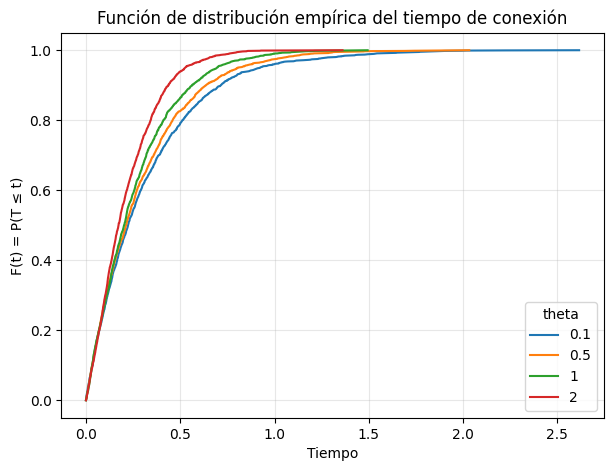

In [ ]:
# =========================================================
# 🔥 CDF EMPÍRICA DEL TIEMPO DE CONEXIÓN
# =========================================================

import numpy as np
import matplotlib.pyplot as plt

def sim_tiempos(tamano_lista, lista, theta, n_sim=300):
    tiempos = []
    for _ in range(n_sim):
        t = ModeloTiemposPrimer(tamano_lista, lista, theta, True)
        tiempos.append(t)
    return np.array(tiempos)


# -----------------------------
# Parámetros
# -----------------------------
thetas = [0.1, 0.5, 1, 2]
tamano_lista = 3
lista = [1,1,1]
n_sim = 2000

# Simular
data = {theta: sim_tiempos(tamano_lista, lista, theta, n_sim) for theta in thetas}


# -----------------------------
# Plot CDF
# -----------------------------
plt.figure(figsize=(7,5))

for theta in thetas:
    x = np.sort(data[theta])
    y = np.arange(1, len(x)+1) / len(x)

    plt.plot(x, y, label=f"{theta}")

plt.title("Función de distribución empírica del tiempo de conexión")
plt.xlabel("Tiempo")
plt.ylabel("F(t) = P(T ≤ t)")
plt.legend(title="theta")
plt.grid(alpha=0.3)

plt.show()

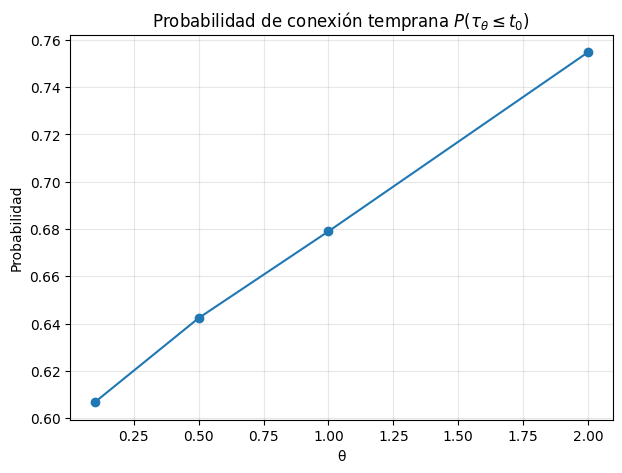

In [ ]:
# =========================================================
# 🔥 PROBABILIDAD DE CONEXIÓN TEMPRANA
# =========================================================

import numpy as np
import matplotlib.pyplot as plt

def sim_tiempos(tamano_lista, lista, theta, n_sim=300):
    tiempos = []
    for _ in range(n_sim):
        t = ModeloTiemposPrimer(tamano_lista, lista, theta, True)
        tiempos.append(t)
    return np.array(tiempos)


# -----------------------------
# Parámetros
# -----------------------------
thetas = [0.1, 0.5, 1, 2]
tamano_lista = 3
lista = [1,1,1]
n_sim = 10000

t0 = 0.3  # tiempo umbral

probs = []

for theta in thetas:
    data = sim_tiempos(tamano_lista, lista, theta, n_sim)
    p = np.mean(data <= t0)
    probs.append(p)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(7,5))

plt.plot(thetas, probs, marker='o')

plt.title(r"Probabilidad de conexión temprana $P(\tau_\theta \leq t_0)$")
plt.xlabel("θ")
plt.ylabel("Probabilidad")
plt.grid(alpha=0.3)

plt.show()